# 0DTE experimental lab (15:30 ATM package)

Same instrument, clocks, smear, and signal as
`atm_straddle_rv_iv.ipynb`. This notebook is the lab for:

1. ensembles of the seven models and of the three paper rules
   (including a causal PCR / spectral ensemble), plus extended causal
   PCA/PCR books (§5b), supervised PLS/PCovR projections (§5c), and
   PCA structure diagnostics (§5d)
2. vol-space maps $\hat y\sqrt{B}$, $m\sqrt{B}$ (stand-in if
   `atm_straddle_volmap.ipynb` is not in the tree)
3. extra weighting rules (rank, inv-vol, dead-zone, vol-target, Kelly-ish)
4. an iron condor lab (§8–§12): width ladder, wing-cost / tail / IR
   diagnostics, strangle bodies with per-side attribution, the §5
   ensembles on the defined-risk instrument, and quoted-spread fill
   sensitivity
5. paired significance (NW + block bootstrap) on the headline deltas
   (§13)
6. the defined-risk book, parked in the RV–IV deck (§14): why wings on selling days do
   not pay per dollar of premium — wing-cost decomposition,
   quoted-spread fills, one-sided wings, a width ladder, and when the
   cap pays
7. cutting exposure on days yesterday's signal ranked high (§15): a
   stand-aside rule scored on the tail against a placebo — a negative
   result; the flag lands on buying days, not on the losses
8. the body itself (§16): a same-strike straddle against the deck's
   nearest out-of-the-money pair — one dollar P&L in three frames, the
   five-point vertical that separates them, offset, fills, and the
   fraction of wealth; the strangle body stays

$R \sim a + b\,s$ lives in `atm_straddle_rv_iv.ipynb`.

Published mid-fill rule tables stay in the RV–IV notebook. Intraday
bars stay in `atm_straddle_intraday.ipynb`.

In [1]:
import hashlib
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import statsmodels.api as sm

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "atm_straddle_lib.py").exists() else Path.cwd() / "notebooks"))
import atm_straddle_lib as asl

REPO = asl.find_repo(Path.cwd())
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl
OUT = REPO / "results" / "atm_straddle_0dte_1530"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Chain, nearest-OTM package, $R$, forecasts, signal

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid", "underlying_price", "impl_volatility"]
_st = os.stat(path)
_ck = CACHE / f"chain_15301600_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))].unique()
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    chain.to_parquet(_ck)
codes, uts = pd.factorize(chain["timestamp"])
uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
chain["et"] = uet.take(codes)
hh = np.where((uet.hour == 15) & (uet.minute == 30), "15:30",
              np.where((uet.hour == 16) & (uet.minute == 0), "16:00", "other"))
chain["hhmm"] = hh[codes]
chain["et_date"] = uet.normalize().take(codes)
ecodes, uexp = pd.factorize(chain["expiration"])
uexp_d = pd.DatetimeIndex(uexp).tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT").normalize()
chain["exp_date"] = uexp_d.take(ecodes)
chain["is_0dte"] = chain["et_date"] == chain["exp_date"]
book_chain = chain[chain["is_0dte"] & chain["hhmm"].isin(["15:30", "16:00"])].copy()
del chain
e = book_chain[book_chain["hhmm"] == "15:30"].copy()
live = e[np.isfinite(e["mid"]) & (e["mid"] > 0)].copy()
spot = live.dropna(subset=["underlying_price"]).groupby("expiration")["underlying_price"].first()
atm = asl.pick_nearest_otm(live, spot)
atm["day"] = atm["et_c"].dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)

def load_gspc_close(days):
    days = pd.to_datetime(days)
    cp = CACHE / "gspc_close.parquet"
    if cp.exists():
        cached = pd.read_parquet(cp)["close"]
        cached.index = pd.to_datetime(cached.index)
        if cached.index.min() <= pd.Timestamp(days.min()) and cached.index.max() >= pd.Timestamp(days.max()):
            return cached.astype(float)
    raw = yf.download("^GSPC", start=pd.Timestamp(days.min()) - pd.Timedelta("7D"),
                      end=pd.Timestamp(days.max()) + pd.Timedelta("7D"),
                      auto_adjust=True, progress=False, threads=True)
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    ix = pd.to_datetime(close.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    close.index = ix.normalize()
    close.rename("close").to_frame().to_parquet(cp)
    return close.astype(float)

exp_day = pd.to_datetime(atm["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
atm["S_close"] = exp_day.map(load_gspc_close(exp_day))
atm["pay_c"] = np.maximum(atm["S_close"] - atm["K_c"], 0.0)
atm["pay_p"] = np.maximum(atm["K_p"] - atm["S_close"], 0.0)
atm["exit"] = atm["pay_c"] + atm["pay_p"]
atm = atm[np.isfinite(atm["entry"]) & np.isfinite(atm["exit"]) & (atm["entry"] > 0)].copy()
atm["R"] = atm["exit"] / atm["entry"] - 1.0
atm = atm.set_index("day").sort_index()
atm = asl.attach_iv_hourly_as_30min(atm)

from concurrent.futures import ThreadPoolExecutor
YHATS = asl.yhat_paths(REPO)
need_dates = set(atm.index)
with ThreadPoolExecutor(max_workers=len(YHATS)) as pool:
    futs = {tag: pool.submit(asl.load_yhat_1530_mz_cached, tag, path, need_dates, CACHE)
            for tag, path in YHATS.items()}
    models = {tag: futs[tag].result() for tag in YHATS}
LABEL = asl.YHAT_LABEL
MODEL_ORDER = asl.MODEL_ORDER

books = {}
for tag, rv in models.items():
    px = atm.join(rv[["rv_hat", "yhat", "m", "yhat_vol", "m_vol", "rv_raw", "baseline"]], how="inner")
    px = px.dropna(subset=["R", "rv_hat", "iv_var"])
    px = px[(px["rv_hat"] > 0) & (px["iv_var"] > 0)]
    px["signal"] = px["rv_hat"] - px["iv_var"]
    px["pos"] = np.where(px["signal"] > 0, 1.0, -1.0)
    books[tag] = px
common = None
for tag in MODEL_ORDER:
    common = books[tag].index if common is None else common.intersection(books[tag].index)
common = common.sort_values()
print("common days", len(common), pd.Timestamp(common.min()), "->", pd.Timestamp(common.max()))


common days 871 2020-01-03 00:00:00 -> 2024-04-30 00:00:00


## 5. Ensemble of the seven models

(a) mean $s$ then sign. (b) majority vote of sign. (c) equal-weight
average of unit-median $q$. (d) trailing-Sharpe and trailing-IR
weights on unit-median $q$ (expanding 63, lag 1). (e) causal spectral /
PCR ensemble of the seven signals (below). Also a 50/50 mix of
always-short and unit-median on blk2, and an equal-weight mix of the
three paper rules on blk2.

**Spectral / PCR.** Let $X_t\in\mathbb{R}^7$ be the vector of model
signals $s=\widehat{RV}-\mathrm{IV}_{30}^{2}$ on day $t$. On days
$u<t$ (min 63) center $X$, take the SVD, and read day $t$ onto the
leading $k$ right singular vectors. Two books:

- *spectral PC1:* $s^{\mathrm{pc1}}_t$ is the PC1 score; sign is
  flipped so PC1 co-moves with the cross-sectional mean $s$. Position
  is $\mathrm{sign}(s^{\mathrm{pc1}})$ or unit-median in that score.
- *PCR $k=1,2$:* regress $R_u$ on the lagged PC scores, apply the
  coefficients to day $t$. Position is $\mathrm{sign}(\hat R_t)$.

The SVD and the PCR fit use only $u<t$. Full-sample eigenvalues are
printed as a diagnostic, not used to trade.

full-sample variance share (diagnostic)
PC1    0.922649
PC2    0.046175
PC3    0.023325
PC4    0.005965
PC5    0.001354
PC6    0.000334
PC7    0.000198
full-sample loadings (sign of PC1 aligned to mean s)
                                   PC1       PC2
HAR + calendar OLS            0.129753  0.059250
block-diag ridge              0.389599  0.397444
LightGBM                      0.419871 -0.529165
XGBoost                       0.386522 -0.586040
lasso (causally tuned)        0.407684  0.218714
lasso (fixed 1e-4)            0.392714  0.397820
elastic net (causally tuned)  0.430413  0.094723


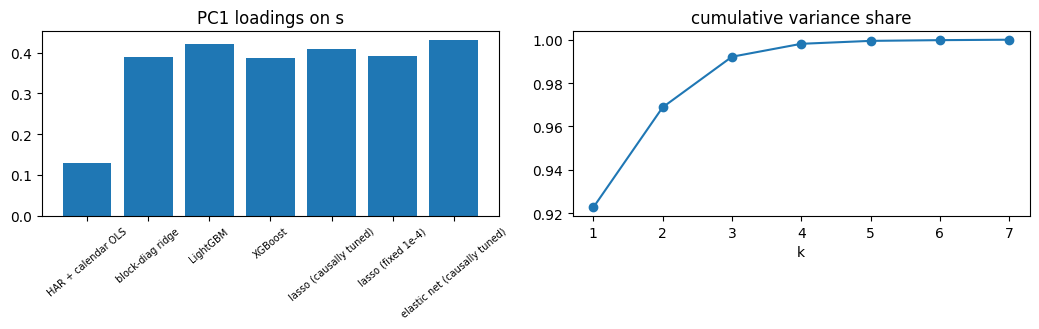

                                   n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
mean-s then sign          871.000000  0.109613  1.121665  -5.422480 -0.652345  0.161679  0.912365  10.316049  0.994760  10.542220  2.884095    1.551318  478.000000  54.879449
majority vote             871.000000  0.108787  1.121745  -5.422480 -0.650023  0.160026  0.915427  10.316049  0.963060  10.554403  2.862134    1.539505  479.000000  54.994259
EW unit-median q          871.000000  0.110976  1.102530  -5.506694 -0.247156  0.040311  0.493161   6.440987 -0.106394   5.245320  2.970638    1.597868  477.000000  54.764638
trail-Sharpe um q         871.000000  0.112506  1.106537  -5.546840 -0.251549  0.045029  0.492904   5.980162 -0.137741   4.867608  3.000663    1.614018  481.000000  55.223881
trail-IR um q             871.000000  0.111477  1.097339  -5.561180 -0.242124  0.039672  0.490298   5.639393 -0.173609   4.89

In [3]:
sig = pd.DataFrame({tag: books[tag]["signal"].loc[common] for tag in MODEL_ORDER})
pos = np.sign(sig).replace(0.0, -1.0)
R = books["blk2"]["R"].loc[common]
um = pd.DataFrame({tag: asl.rule_sizes(books[tag])["unit-median VRP"].loc[common] for tag in MODEL_ORDER})

ens = {}
ens["mean-s then sign"] = np.sign(sig.mean(axis=1)).replace(0.0, -1.0) * R
ens["majority vote"] = np.sign(pos.sum(axis=1)).replace(0.0, -1.0) * R
ens["EW unit-median q"] = um.mean(axis=1) * R

def trailing_w(q: pd.DataFrame, kind: str) -> pd.Series:
    w_hist = []
    idx = q.index
    out = pd.Series(0.0, index=idx)
    for i, t in enumerate(idx):
        if i < 63:
            w = np.ones(q.shape[1]) / q.shape[1]
        else:
            sl = slice(0, i)
            scores = []
            for col in q.columns:
                rp = (q[col] * R).iloc[sl]
                mu, sd = float(rp.mean()), float(rp.std(ddof=1))
                if kind == "sharpe":
                    scores.append(mu / sd if sd > 0 else 0.0)
                else:
                    active = rp - (-R.iloc[sl])
                    a_sd = float(active.std(ddof=1))
                    scores.append(float(active.mean()) / a_sd if a_sd > 0 else 0.0)
            w = np.maximum(np.array(scores, float), 0.0)
            w = w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)
        out.iloc[i] = float((q.iloc[i] * w).sum())
    return out

ens["trail-Sharpe um q"] = trailing_w(um, "sharpe") * R
ens["trail-IR um q"] = trailing_w(um, "ir") * R
blk_sizes = asl.rule_sizes(books["blk2"])
ens["blk2 0.5 AS + 0.5 UM"] = (0.5 * blk_sizes["always short"] + 0.5 * blk_sizes["unit-median VRP"]).loc[common] * R
ens["blk2 EW 3 rules"] = (
    blk_sizes["always short"] + blk_sizes["sign(s)"] + blk_sizes["unit-median VRP"]
).loc[common] / 3.0 * R
ens["blk2 unit-median (bench)"] = blk_sizes["unit-median VRP"].loc[common] * R
ens["blk2 sign(s)"] = blk_sizes["sign(s)"].loc[common] * R
ens["always short"] = blk_sizes["always short"].loc[common] * R

# Causal spectral / PCR ensemble of the 7-vector of signals.
# Day t sees only X[:t] (strict). Min 63 days; earlier days sit at EW sign.
X = sig.to_numpy(float)
r = R.to_numpy(float)
n, p = X.shape
s_pc1 = np.full(n, np.nan)
rhat_k1 = np.full(n, np.nan)
rhat_k2 = np.full(n, np.nan)
loadings_last = None
for t in range(n):
    if t < 63:
        s_pc1[t] = float(X[t].mean())
        rhat_k1[t] = s_pc1[t]
        rhat_k2[t] = s_pc1[t]
        continue
    past = X[:t]
    mu = past.mean(axis=0)
    Xc = past - mu
    # economy SVD on T x 7
    _, S_sing, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0]
    if np.dot(v1, np.ones(p)) < 0:
        v1 = -v1
        Vt = Vt.copy()
        Vt[0] = v1
    xt = X[t] - mu
    z1 = float(xt @ Vt[0])
    z2 = float(xt @ Vt[1])
    s_pc1[t] = z1
    Z1 = Xc @ Vt[0]
    Z2 = np.column_stack([Z1, Xc @ Vt[1]])
    y = r[:t]
    def ols_apply(Z, y, znew):
        Z1c = np.column_stack([np.ones(len(y)), Z])
        beta, *_ = np.linalg.lstsq(Z1c, y, rcond=None)
        z = np.concatenate([[1.0], np.atleast_1d(znew)])
        return float(z @ beta)
    rhat_k1[t] = ols_apply(Z1, y, z1)
    rhat_k2[t] = ols_apply(Z2, y, [z1, z2])
    loadings_last = (S_sing, Vt)

s_pc1 = pd.Series(s_pc1, index=sig.index)
rhat_k1 = pd.Series(rhat_k1, index=sig.index)
rhat_k2 = pd.Series(rhat_k2, index=sig.index)
q_pc1 = np.sign(s_pc1).replace(0.0, -1.0)
q_pcr1 = np.sign(rhat_k1).replace(0.0, -1.0)
q_pcr2 = np.sign(rhat_k2).replace(0.0, -1.0)
q_pc1_um = q_pc1 * asl.causal_leverage(s_pc1)
ens["spectral PC1 sign"] = q_pc1 * R
ens["spectral PC1 unit-median"] = q_pc1_um * R
ens["PCR k=1 sign"] = q_pcr1 * R
ens["PCR k=2 sign"] = q_pcr2 * R

# Full-sample SVD diagnostic only (not a trading input).
Xc_all = X - X.mean(axis=0)
_, S_all, Vt_all = np.linalg.svd(Xc_all, full_matrices=False)
share = S_all**2 / (S_all**2).sum()
load_tab = pd.DataFrame(Vt_all[:2].T, index=[LABEL[t] for t in MODEL_ORDER], columns=["PC1", "PC2"])
if np.dot(load_tab["PC1"], np.ones(p)) < 0:
    load_tab["PC1"] *= -1
print("full-sample variance share (diagnostic)")
print(pd.Series(share, index=[f"PC{i+1}" for i in range(p)]).to_string())
print("full-sample loadings (sign of PC1 aligned to mean s)")
print(load_tab.to_string())
load_tab.to_csv(OUT / "ensemble_spectral_loadings.csv")
pd.Series(share, index=[f"PC{i+1}" for i in range(p)]).to_csv(OUT / "ensemble_spectral_varshare.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
axes[0].bar(load_tab.index, load_tab["PC1"].to_numpy())
axes[0].set_title("PC1 loadings on s")
axes[0].tick_params(axis="x", rotation=40, labelsize=7)
axes[1].plot(np.arange(1, p + 1), share.cumsum(), marker="o")
axes[1].set_title("cumulative variance share")
axes[1].set_xlabel("k")
fig.tight_layout()
fig.savefig(OUT / "ensemble_spectral_pca.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

ens_tab = pd.DataFrame({k: asl.rule_row(v, np.sign(v).replace(0, -1)) for k, v in ens.items()}).T
print(ens_tab.to_string())
ens_tab.to_csv(OUT / "ensemble_summary.csv")
pd.DataFrame(ens).to_csv(OUT / "ensemble_daily.csv")
print("saved ensemble_*.csv")


## 5b. Causal PCA/PCR books — where the ensemble information lives

Extensions of the §5 spectral machinery, same protocol throughout: day
$t$ uses the SVD of the centered signal matrix on days $u<t$ only
(min 63; earlier days sit at the EW mean-signal fallback), and PC1's
sign co-moves with the cross-sectional mean $s$. Nothing here is a
search for a better rule — the table maps where the ensemble
information lives.

- *PCR $k$-sweep:* regress $R_u$ on the first $k$ lagged PC scores,
  $k=1,\dots,7$, apply the coefficients to day $t$, trade
  $\mathrm{sign}(\hat R_t)$. Fitted values are invariant to component
  sign flips, so the sweep needs no convention beyond PC1's.
- *PC2 / PC3 sign books:* $q_t=\mathrm{sign}(\hat\beta_{j,t})\,
  \mathrm{sign}(z_{j,t})$, where $\hat\beta_{j,t}$ is the OLS slope of
  $R_u$ on the past PC$_j$ scores — the sign convention is itself
  estimated only from $u<t$.
- *PCR $k{=}1$ unit-median:* unit-median leverage in the fitted value
  $\hat R$ (expanding median of $|\hat R|$, lag 1, cap 3).
- *PC1-of-$q$:* the same causal PC1 taken on the 7-vector of signed
  unit-median positions $q$ instead of raw $s$; trade the sign of the
  score.

Benchmarks repeat from §5. The first four rows reproduce the §5 books
exactly; the in-cell check prints the max $|R'|$ discrepancy against
`ens`.

In [4]:
X = sig.to_numpy(float)
r = R.to_numpy(float)
n, p = X.shape
scores = np.full((n, p), np.nan)
bsign = np.ones((n, p))
rhat_k = {k: np.full(n, np.nan) for k in range(1, p + 1)}
for t in range(n):
    if t < 63:
        ew = float(X[t].mean())
        scores[t, :] = ew
        for k in rhat_k:
            rhat_k[k][t] = ew
        continue
    past = X[:t]
    mu = past.mean(axis=0)
    Xc = past - mu
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    if np.dot(Vt[0], np.ones(p)) < 0:
        Vt = Vt.copy()
        Vt[0] = -Vt[0]
    xt = X[t] - mu
    z = xt @ Vt.T
    Z = Xc @ Vt.T
    scores[t] = z
    y = r[:t]
    for j in range(p):
        bsign[t, j] = 1.0 if float(Z[:, j] @ y) >= 0 else -1.0
    ones = np.ones((t, 1))
    for k in range(1, p + 1):
        Zk = np.column_stack([ones, Z[:, :k]])
        beta, *_ = np.linalg.lstsq(Zk, y, rcond=None)
        rhat_k[k][t] = float(np.concatenate([[1.0], z[:k]]) @ beta)

idx = sig.index
s_pc1x = pd.Series(scores[:, 0], index=idx)
rhat = {k: pd.Series(v, index=idx) for k, v in rhat_k.items()}


def _sgn(x):
    return np.sign(x).replace(0.0, -1.0)


pca_books = {}
q1 = _sgn(s_pc1x)
pca_books["spectral PC1 sign"] = q1 * R
pca_books["spectral PC1 unit-median"] = q1 * asl.causal_leverage(s_pc1x) * R
for k in range(1, p + 1):
    pca_books[f"PCR k={k} sign"] = _sgn(rhat[k]) * R
pca_books["PCR k=1 unit-median"] = _sgn(rhat[1]) * asl.causal_leverage(rhat[1]) * R
for j in (1, 2):
    zj = pd.Series(scores[:, j] * bsign[:, j], index=idx)
    pca_books[f"PC{j+1} sign (beta-aligned)"] = _sgn(zj) * R

# Causal PC1 on the 7-vector of signed unit-median positions q.
Xq = um.to_numpy(float)
s_q1 = np.full(n, np.nan)
for t in range(n):
    if t < 63:
        s_q1[t] = float(Xq[t].mean())
        continue
    past = Xq[:t]
    mu = past.mean(axis=0)
    Xc = past - mu
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0] if np.dot(Vt[0], np.ones(p)) >= 0 else -Vt[0]
    s_q1[t] = float((Xq[t] - mu) @ v1)
s_q1 = pd.Series(s_q1, index=idx)
pca_books["PC1-of-q sign"] = _sgn(s_q1) * R

pca_books["EW unit-median q"] = ens["EW unit-median q"]
pca_books["blk2 unit-median (bench)"] = ens["blk2 unit-median (bench)"]
pca_books["always short"] = ens["always short"]

chk = max(
    float((pca_books[k_] - ens[k_]).abs().max())
    for k_ in ("spectral PC1 sign", "spectral PC1 unit-median",
               "PCR k=1 sign", "PCR k=2 sign")
)
print("max |R' diff| vs the §5 books:", chk)
pca_tab = pd.DataFrame({k: asl.rule_row(v, _sgn(v)) for k, v in pca_books.items()}).T
print(pca_tab.to_string())
pca_tab.to_csv(OUT / "pca_lab_books.csv")
print("saved", OUT / "pca_lab_books.csv")


max |R' diff| vs the §5 books: 8.881784197001252e-16
                                   n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
spectral PC1 sign         871.000000  0.083094  1.123943 -10.316049 -0.489474  0.268846  0.932559   6.836034 -1.324720  11.237965  2.181889    1.173610  514.000000  59.012629
spectral PC1 unit-median  871.000000  0.033988  0.899238  -6.124124 -0.143283  0.044021  0.375430   6.836034 -0.777301  11.853711  1.115480    0.600003  514.000000  59.012629
PCR k=1 sign              871.000000 -0.028898  1.126643 -10.316049 -0.754070  0.056846  0.819001   6.836034 -1.138689  10.623474 -0.756985   -0.407172  447.000000  51.320321
PCR k=2 sign              871.000000 -0.006286  1.126996 -10.316049 -0.729437  0.110074  0.837196   6.836034 -1.140620  10.701817 -0.164603   -0.088538  464.000000  53.272101
PCR k=3 sign              871.000000 -0.006712  1.126994 -10.316049 -0.7

## 5c. Causal supervised projections (PLS / PCovR)

Section 5's PC1/PCR books are unsupervised: the direction is chosen by
the variance of the seven signals, and $R$ enters only through the PCR
coefficients. Here the *direction itself* is supervised, with the same
strict causality as §5 (day $t$ uses $X_{u<t}$, $R_{u<t}$ only; min 63;
earlier days sit at the EW-mean score). Nothing here is a search for a
better rule — it maps whether supervision adds anything over PC1. The
lab's standing result is that ensembles do not beat blk2 unit-median,
so a null is the expected answer.

- *PLS1:* $w\propto X_c^{\top}R_c$ (the covariance-with-target
  direction), $\|w\|=1$; score $z_t=(x_t-\mu)^{\top}w$. Books:
  $\mathrm{sign}(z)$ and unit-median in $z$.
- *PLS2:* one NIPALS deflation ($X_c^{(2)}=X_c-t_1p_1^{\top}$,
  $w_2\propto X_c^{(2)\top}R_c$), then OLS of $R$ on $[z_1,z_2]$ with
  intercept, applied to day $t$ — the supervised analog of PCR $k=2$.
  Book: $\mathrm{sign}(\hat R_t)$.
- *PCovR blend:* leading eigenvector of
  $\alpha\,G_1/\mathrm{tr}\,G_1+(1-\alpha)\,G_2/\mathrm{tr}\,G_2$ with
  $G_1=(X_c^{\top}R_c)(X_c^{\top}R_c)^{\top}$, $G_2=X_c^{\top}X_c$,
  $\alpha\in\{0.25,0.5,0.75\}$; each Gram is normalized by its trace so
  the mix is scale-free. Sign aligned so the score co-moves with the
  PLS1 direction. Book: $\mathrm{sign}(z)$.

Columns as in §5's ensemble table (`asl.rule_row`; daily book,
$\sqrt{252}$). Benchmarks are pulled from §5's `ens` dict, not
recomputed.

In [5]:
PLS_ALPHAS = (0.25, 0.5, 0.75)
z_pls1 = np.full(n, np.nan)
rhat_pls2 = np.full(n, np.nan)
z_pcovr = {a: np.full(n, np.nan) for a in PLS_ALPHAS}

def _ols_apply(Z, y, znew):
    Z1c = np.column_stack([np.ones(len(y)), Z])
    beta, *_ = np.linalg.lstsq(Z1c, y, rcond=None)
    z = np.concatenate([[1.0], np.atleast_1d(znew)])
    return float(z @ beta)

for t in range(n):
    if t < 63:
        ew = float(X[t].mean())
        z_pls1[t] = ew
        rhat_pls2[t] = ew
        for a in PLS_ALPHAS:
            z_pcovr[a][t] = ew
        continue
    past = X[:t]
    mu = past.mean(axis=0)
    Xc = past - mu
    y = r[:t]
    yc = y - y.mean()
    xt = X[t] - mu

    # PLS1: covariance-with-target direction, unit norm.
    w1 = Xc.T @ yc
    nw = float(np.linalg.norm(w1))
    w1 = np.ones(p) / np.sqrt(p) if nw == 0 else w1 / nw
    z1 = float(xt @ w1)
    z_pls1[t] = z1

    # PLS2: one NIPALS deflation, then OLS of R on [z1, z2] with intercept.
    T1 = Xc @ w1
    tt = float(T1 @ T1)
    p1 = Xc.T @ T1 / tt if tt > 0 else np.zeros(p)
    Xc2 = Xc - np.outer(T1, p1)
    w2 = Xc2.T @ yc
    nw2 = float(np.linalg.norm(w2))
    w2 = np.zeros(p) if nw2 == 0 else w2 / nw2
    z2 = float((xt - float(xt @ w1) * p1) @ w2)
    rhat_pls2[t] = _ols_apply(np.column_stack([T1, Xc2 @ w2]), y, [z1, z2])

    # PCovR blend: leading eigenvector of the trace-normalized Gram mix.
    g = Xc.T @ yc
    G1 = np.outer(g, g)
    G2 = Xc.T @ Xc
    tr1, tr2 = float(np.trace(G1)), float(np.trace(G2))
    for a in PLS_ALPHAS:
        M = np.zeros((p, p))
        if tr1 > 0:
            M = M + a * G1 / tr1
        if tr2 > 0:
            M = M + (1.0 - a) * G2 / tr2
        _, vecs = np.linalg.eigh(M)
        v = vecs[:, -1]
        ref = g if float(np.linalg.norm(g)) > 0 else np.ones(p)
        if float(v @ ref) < 0:
            v = -v
        z_pcovr[a][t] = float(xt @ v)

z_pls1 = pd.Series(z_pls1, index=sig.index)
rhat_pls2 = pd.Series(rhat_pls2, index=sig.index)

sup = {}
q_pls1 = np.sign(z_pls1).replace(0.0, -1.0)
sup["PLS1 sign"] = q_pls1 * R
sup["PLS1 unit-median"] = q_pls1 * asl.causal_leverage(z_pls1) * R
sup["PLS2 rhat sign"] = np.sign(rhat_pls2).replace(0.0, -1.0) * R
for a in PLS_ALPHAS:
    za = pd.Series(z_pcovr[a], index=sig.index)
    sup[f"PCovR a={a} sign"] = np.sign(za).replace(0.0, -1.0) * R
for k in ("PCR k=1 sign", "spectral PC1 sign", "EW unit-median q",
          "blk2 unit-median (bench)", "always short"):
    sup[k] = ens[k]

pls_tab = pd.DataFrame({k: asl.rule_row(v, np.sign(v).replace(0, -1)) for k, v in sup.items()}).T
print(pls_tab.to_string())
pls_tab.to_csv(OUT / "pca_lab_pls.csv")
n_flip = int((np.sign(pd.Series(z_pcovr[0.25], index=sig.index))
              != np.sign(pd.Series(z_pcovr[0.75], index=sig.index))).sum())
print("PCovR sign flips between a=0.25 and a=0.75:", n_flip)
print("saved", OUT / "pca_lab_pls.csv")


                                   n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
PLS1 sign                 871.000000  0.006414  1.126996 -10.316049 -0.645985  0.163874  0.880598   6.836034 -1.334045  10.757918  0.167969    0.090348  481.000000  55.223881
PLS1 unit-median          871.000000  0.037305  1.220574 -10.622293 -0.353850  0.069876  0.530741  10.652714 -0.357503  16.960051  0.902002    0.485176  481.000000  55.223881
PLS2 rhat sign            871.000000 -0.011311  1.126957 -10.316049 -0.737386  0.099442  0.829974   6.836034 -1.129317  10.683329 -0.296199   -0.159322  460.000000  52.812859
PCovR a=0.25 sign         871.000000  0.007638  1.126988 -10.316049 -0.787543  0.002267  0.798172   6.836034 -0.730301  10.747589  0.200031    0.107594  436.000000  50.057405
PCovR a=0.5 sign          871.000000  0.006732  1.126994 -10.316049 -0.745648  0.055724  0.821556   6.836034 -0.855496  10.74

## 5d. PCA structure diagnostics

How much structure is there in the seven signals, and how many
independent bets are the seven books? **Diagnostics only — nothing
here is a trading input.** Six views:

- *Correlation / sign agreement.* Pearson correlation of the daily
  $s$ vectors and pairwise sign-agreement %. Answers: how far from
  one signal are the seven models?
- *Expanding causal PC1 share.* At each $t\ge 63$, PC1 variance share
  of the SVD of $X_{u<t}$ — the factor strength a day-$t$ trader
  would have seen. Answers: does the one-factor structure
  strengthen or decay?
- *Loading stability.* PC1 loadings at expanding cutoffs
  (every 21 days). Answers: does any model rotate in or out of the
  factor?
- *Risk-space PCA.* Full-sample PCA of the seven unit-median book
  returns $q_i R$. Answers: how many independent bets are the seven
  books in return space?
- *PC1 vs mean.* Full-sample PC1 score against the cross-sectional
  mean $s$. Answers: is PC1 anything other than the equal-weight
  mean?
- *$R^2$ ladder.* Full-sample $R^2$ of daily $R$ on the first $k$ PC
  scores, $k=1..7$ — the in-sample ceiling for the causal PCR books
  of §5.

Pearson correlation of daily signals s (diagnostic)
               a0      blk2      lgbm       xgb   lasso_t   lasso_f      enet
a0       1.000000  0.756577  0.661551  0.687973  0.624824  0.738351  0.640984
blk2     0.756577  1.000000  0.866614  0.851659  0.945583  0.996922  0.935738
lgbm     0.661551  0.866614  1.000000  0.991010  0.908918  0.873951  0.934937
xgb      0.687973  0.851659  0.991010  1.000000  0.870153  0.852366  0.895543
lasso_t  0.624824  0.945583  0.908918  0.870153  1.000000  0.960637  0.989653
lasso_f  0.738351  0.996922  0.873951  0.852366  0.960637  1.000000  0.952151
enet     0.640984  0.935738  0.934937  0.895543  0.989653  0.952151  1.000000
pairwise sign-agreement % (diagnostic)
                 a0        blk2        lgbm         xgb     lasso_t     lasso_f        enet
a0       100.000000   83.352468   87.600459   88.404133   85.763490   81.974742   85.648680
blk2      83.352468  100.000000   81.974742   80.711825   88.633754   94.489093   88.518944
lgbm     

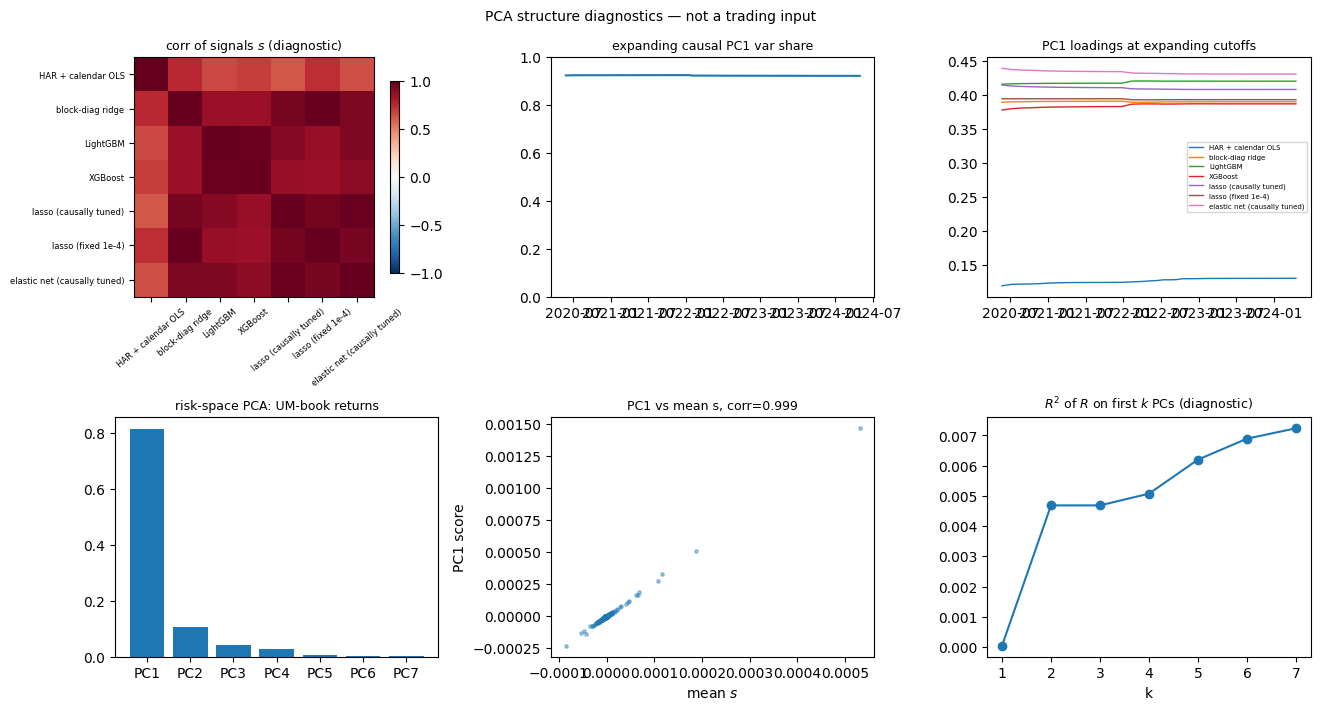

saved pca_lab_structure.png + pca_lab_*.csv


In [6]:
n, p = X.shape
names = [LABEL[t] for t in MODEL_ORDER]

corr = sig.corr()
pos_d = np.sign(sig).replace(0.0, -1.0)
agree = pd.DataFrame(
    {ci: {cj: float((pos_d[ci] == pos_d[cj]).mean() * 100.0) for cj in MODEL_ORDER} for ci in MODEL_ORDER}
).T.loc[MODEL_ORDER, MODEL_ORDER]
print("Pearson correlation of daily signals s (diagnostic)")
print(corr.to_string())
print("pairwise sign-agreement % (diagnostic)")
print(agree.to_string())
corr.to_csv(OUT / "pca_lab_sig_corr.csv")
agree.to_csv(OUT / "pca_lab_sign_agree.csv")

# expanding causal PC1 variance share: what a day-t trader would have seen
share_ts = np.full(n, np.nan)
for t in range(63, n):
    past = X[:t]
    Xc = past - past.mean(axis=0)
    s_sing = np.linalg.svd(Xc, compute_uv=False)
    share_ts[t] = float(s_sing[0] ** 2 / (s_sing**2).sum())
share_ts = pd.Series(share_ts, index=sig.index, name="pc1_share")
print("expanding causal PC1 share: first %.4f last %.4f min %.4f max %.4f"
      % (share_ts.dropna().iloc[0], share_ts.dropna().iloc[-1], share_ts.min(), share_ts.max()))
share_ts.to_csv(OUT / "pca_lab_pc1_share_ts.csv")

# PC1 loadings at expanding cutoffs (~monthly), sign aligned to the mean
traj_rows = {}
for c in range(63, n + 1, 21):
    past = X[:c]
    Xc = past - past.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0] if np.dot(Vt[0], np.ones(p)) >= 0 else -Vt[0]
    traj_rows[sig.index[c - 1]] = v1
traj = pd.DataFrame(traj_rows, index=MODEL_ORDER).T
print("PC1 loading range over expanding cutoffs")
print(pd.DataFrame({"min": traj.min(), "max": traj.max()}).to_string())
traj.to_csv(OUT / "pca_lab_loadings_traj.csv")

# risk-space PCA: how many independent bets are the 7 UM books?
rets = um.mul(R, axis=0)
Rc = rets.to_numpy(float)
Rc = Rc - Rc.mean(axis=0)
s_r = np.linalg.svd(Rc, compute_uv=False)
share_risk = pd.Series(s_r**2 / (s_r**2).sum(), index=[f"PC{i+1}" for i in range(p)])
print("risk-space PCA variance share (7 UM-book daily returns, diagnostic)")
print(share_risk.to_string())
share_risk.to_csv(OUT / "pca_lab_riskspace_share.csv")

# full-sample PC1 vs mean s, and the R^2 ladder
Xc_f = X - X.mean(axis=0)
_, S_f, Vt_f = np.linalg.svd(Xc_f, full_matrices=False)
if np.dot(Vt_f[0], np.ones(p)) < 0:
    Vt_f = Vt_f.copy()
    Vt_f[0] = -Vt_f[0]
z1 = Xc_f @ Vt_f[0]
mean_s = sig.mean(axis=1).to_numpy()
corr_pc1_mean = float(np.corrcoef(z1, mean_s)[0, 1])
print(f"corr(full-sample PC1 score, mean s) = {corr_pc1_mean:.4f}")

y = R.to_numpy(float)
sst = float(((y - y.mean()) ** 2).sum())
r2 = {}
for k in range(1, p + 1):
    Z1 = np.column_stack([np.ones(n), Xc_f @ Vt_f[:k].T])
    beta, *_ = np.linalg.lstsq(Z1, y, rcond=None)
    r2[k] = 1.0 - float(((y - Z1 @ beta) ** 2).sum()) / sst
r2 = pd.Series(r2, name="R2")
print("full-sample R^2 of daily R on first k PC scores (diagnostic ceiling)")
print(r2.to_string())
r2.to_csv(OUT / "pca_lab_r2_ladder.csv")

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2))
ax = axes[0, 0]
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(p), names, rotation=40, fontsize=6)
ax.set_yticks(range(p), names, fontsize=6)
ax.set_title("corr of signals $s$ (diagnostic)", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax = axes[0, 1]
ax.plot(share_ts.index, share_ts.to_numpy())
ax.set_title("expanding causal PC1 var share", fontsize=9)
ax.set_ylim(0, 1)
ax = axes[0, 2]
for tag in MODEL_ORDER:
    ax.plot(traj.index, traj[tag], label=LABEL[tag], lw=1)
ax.set_title("PC1 loadings at expanding cutoffs", fontsize=9)
ax.legend(fontsize=5)
ax = axes[1, 0]
ax.bar(share_risk.index, share_risk.to_numpy())
ax.set_title("risk-space PCA: UM-book returns", fontsize=9)
ax = axes[1, 1]
ax.scatter(mean_s, z1, s=6, alpha=0.4)
ax.set_xlabel("mean $s$")
ax.set_ylabel("PC1 score")
ax.set_title(f"PC1 vs mean s, corr={corr_pc1_mean:.3f}", fontsize=9)
ax = axes[1, 2]
ax.plot(r2.index, r2.to_numpy(), marker="o")
ax.set_xlabel("k")
ax.set_title("$R^2$ of $R$ on first $k$ PCs (diagnostic)", fontsize=9)
fig.suptitle("PCA structure diagnostics — not a trading input", fontsize=10)
fig.tight_layout()
fig.savefig(OUT / "pca_lab_structure.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved pca_lab_structure.png + pca_lab_*.csv")


## 6. Vol-space maps

Stand-in for `atm_straddle_volmap.ipynb`: $\hat y\sqrt{B}$ and
$m\sqrt{B}$ against $\mathrm{IV}_{30}$ and $\sqrt{\mathrm{rv\_raw}}$.

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\volmap_a0_blk2.png


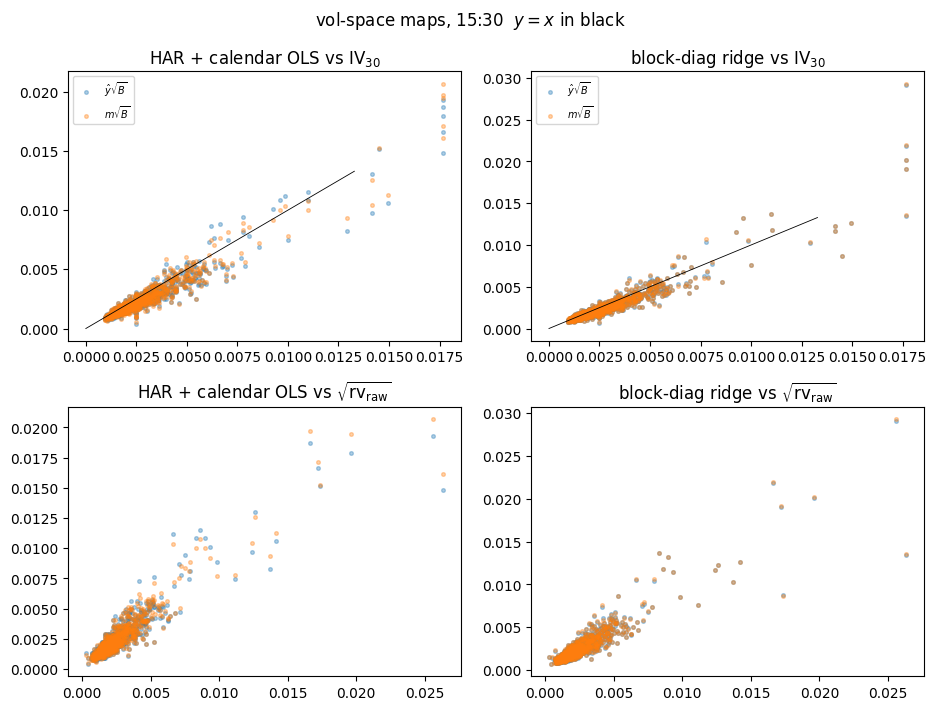

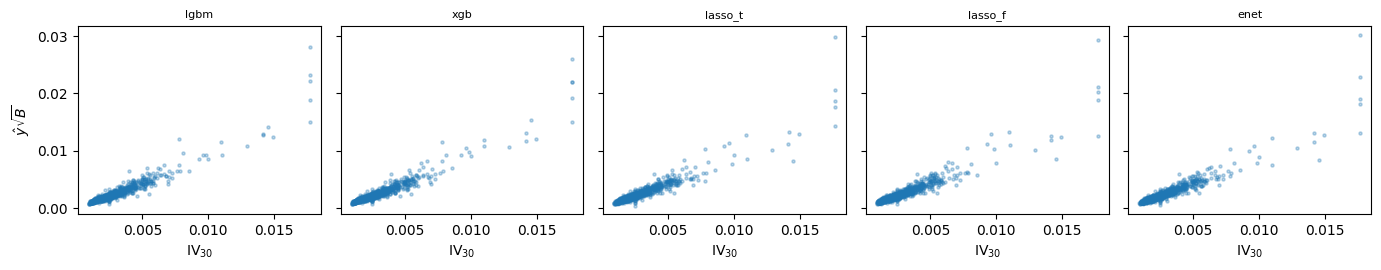

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.2))
for col, tag in enumerate(("a0", "blk2")):
    px = books[tag].loc[common]
    axes[0, col].scatter(px["iv_30"], px["yhat_vol"], s=7, alpha=0.35, label=r"$\hat y\sqrt{B}$")
    axes[0, col].scatter(px["iv_30"], px["m_vol"], s=7, alpha=0.35, label=r"$m\sqrt{B}$")
    axes[0, col].set_title(LABEL[tag] + r" vs $\mathrm{IV}_{30}$")
    axes[0, col].legend(fontsize=7)
    axes[1, col].scatter(np.sqrt(px["rv_raw"].clip(lower=0)), px["yhat_vol"], s=7, alpha=0.35)
    axes[1, col].scatter(np.sqrt(px["rv_raw"].clip(lower=0)), px["m_vol"], s=7, alpha=0.35)
    axes[1, col].set_title(LABEL[tag] + r" vs $\sqrt{\mathrm{rv_{raw}}}$")
    lo, hi = 0, float(np.nanpercentile(px["iv_30"], 99))
    axes[0, col].plot([lo, hi], [lo, hi], color="k", lw=0.6)
fig.suptitle(r"vol-space maps, 15:30  $y=x$ in black")
fig.tight_layout()
fig.savefig(OUT / "volmap_a0_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "volmap_a0_blk2.png")
display(fig)
plt.close(fig)

fig, axes = plt.subplots(1, 5, figsize=(14, 2.8), sharey=True)
for ax, tag in zip(axes, ("lgbm", "xgb", "lasso_t", "lasso_f", "enet")):
    px = books[tag].loc[common]
    ax.scatter(px["iv_30"], px["yhat_vol"], s=5, alpha=0.3)
    ax.set_title(tag, fontsize=8)
    ax.set_xlabel(r"$\mathrm{IV}_{30}$")
axes[0].set_ylabel(r"$\hat y\sqrt{B}$")
fig.tight_layout()
fig.savefig(OUT / "volmap_yhat_vs_iv_rest.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 7. Other well-motivated weighting strategies

Rank of $|s|$, inverse expanding vol of $R$, dead-zone at half the
expanding median, vol-target of the unit-median book, and a Kelly-ish
$q=\mathrm{clip}(s/\widehat{\mathrm{Var}}(R),-3,3)$. Scored on the
common days. blk2 shown; CSVs for every model.

In [8]:
extra_names = ["rank-|s|", "inv-vol of R", "dead-zone 0.5 med",
               "vol-target unit-median", "kelly-ish s/var(R)"]
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = asl.extra_weight_sizes(px)
    tab = pd.DataFrame({
        name: asl.rule_row((sizes[name] * px["R"]).loc[common], sizes[name].loc[common])
        for name in extra_names + ["unit-median VRP", "always short"]
    }).T
    tab.to_csv(OUT / f"experimental_weights_{tag}.csv")
    if tag == "blk2":
        print("blk2 extra weights")
        print(tab.to_string())
print("saved experimental_weights_*.csv")


blk2 extra weights
                                 n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
rank-|s|                871.000000  0.073213  1.060501  -6.005754 -0.119973  0.000000  0.393044   6.836034  0.122769   8.405007  2.037460    1.095924  226.000000  25.947187
inv-vol of R            871.000000  0.114914  1.118989  -5.490101 -0.668194  0.152892  0.881076  10.399342  0.985359  11.037217  3.030805    1.630231  339.000000  38.920781
dead-zone 0.5 med       871.000000  0.059074  0.693408  -3.550905  0.000000  0.000000  0.284820   4.254864  0.011073   5.837456  2.514302    1.352411  140.000000  16.073479
vol-target unit-median  871.000000  0.093894  1.006777  -7.907255 -0.177053  0.010880  0.389763   7.094713 -0.347579  10.591333  2.752417    1.480490  296.000000  33.983927
kelly-ish s/var(R)      871.000000  0.000000  0.000003  -0.000029 -0.000000  0.000000  0.000001   0.000023 -1.417522

saved experimental_weights_*.csv


## 8. Iron condor lab: width ladder

Body is the §1 nearest-OTM package; wings are the nearest live 15:30
mids at least $w$ points further OTM (`asl.pick_wings`; the same wing
selection as the defined-risk book parked in the RV–IV deck and explored in §14 here). Short
iron condor = short body + long wings.
Defined-risk long-package return is
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply unchanged; the three rules use the blk2
signal. Credit-denominator $R$ stays a warning only
(`frac_entry_ic_le0` is the fraction of days with net credit
$\le 0$).

Two width families:

- *fixed:* $w\in\{10,25,50,75,100\}$ points.
- *vol-scaled:* $w = c\cdot\mathrm{entry}_{\mathrm{body}}$,
  $c\in\{1,2,4\}$. The package price is the natural vol-dollar unit
  (it is the market's expected move to the close), so wings sit at a
  roughly constant moneyness-in-vol instead of a constant point
  distance. Bounded by construction: $\mathrm{entry}>0$ on every
  scored day. The realized width snaps up to the strike grid;
  `med_eff_width` reports the median realized width.

Coverage at these widths is full (both wings live on all 1291 body
days; nothing dropped), so every row is scored on the same blk2
`common` days. A wider ladder would start dropping exactly the
high-vol days — re-check coverage before extending it.

Columns: `n` days scored; `mean`/`std` of $R'=q\,R_{\mathrm{long,ic}}$;
`t_mean` $=\bar R'/\mathrm{sd}\times\sqrt{n}$; `Sharpe_ann`
$=\bar R'/\mathrm{sd}\times\sqrt{252}$ (one package per day, daily
annualization is correct here); `pct_buy` per cent of days with
$q>0$; `med_credit` median $\mathrm{entry}_{ic}$.

w10: days with both wings 1291 / body 1291 dropped 0


w25: days with both wings 1291 / body 1291 dropped 0


w50: days with both wings 1291 / body 1291 dropped 0


w75: days with both wings 1291 / body 1291 dropped 0


w100: days with both wings 1291 / body 1291 dropped 0


c1xentry: days with both wings 1291 / body 1291 dropped 0


c2xentry: days with both wings 1291 / body 1291 dropped 0


c4xentry: days with both wings 1291 / body 1291 dropped 0


--- condor width ladder, defined-risk R, blk2, common days ---
                                   n      mean       std    t_mean  Sharpe_ann    pct_buy  med_eff_width  med_credit  frac_entry_ic_le0
width    rule                                                                                                                          
w10      always short     871.000000 -0.004845  0.358407 -0.398942   -0.214586   0.000000      10.000000    4.325000           0.000775
         sign(s)          871.000000  0.024956  0.357569  2.059760    1.107918  38.920781      10.000000    4.325000           0.000775
         unit-median VRP  871.000000  0.019890  0.523166  1.122003    0.603511  38.920781      10.000000    4.325000           0.000775
w25      always short     871.000000  0.001076  0.237364  0.133792    0.071965   0.000000      25.000000    5.200000           0.000775
         sign(s)          871.000000  0.016519  0.236790  2.058810    1.107408  38.920781      25.000000    5.200000     

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\condor_lab_width_ladder.png


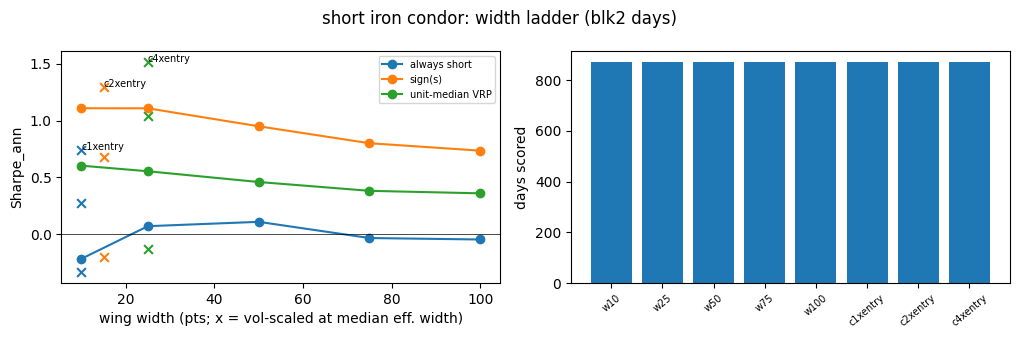

In [9]:
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()

def pick_wings_perday(live_q: pd.DataFrame, body_df: pd.DataFrame, w_row) -> pd.DataFrame:
    # asl.pick_wings with a per-day width; w_row is aligned to body_df rows.
    c = live_q[live_q["cp"] == "C"].copy()
    p = live_q[live_q["cp"] == "P"].copy()
    want_c = body_df[["expiration", "K_c"]].copy()
    want_p = body_df[["expiration", "K_p"]].copy()
    want_c["w"] = np.asarray(w_row, float)
    want_p["w"] = np.asarray(w_row, float)
    c = c.merge(want_c, on="expiration", how="inner")
    p = p.merge(want_p, on="expiration", how="inner")
    c = c[c["strike"].astype(float) >= (c["K_c"] + c["w"])]
    p = p[p["strike"].astype(float) <= (p["K_p"] - p["w"])]
    c["k_gap"] = c["strike"].astype(float) - c["K_c"]
    p["k_gap"] = p["K_p"] - p["strike"].astype(float)
    c_w = c.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    p_w = p.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    wings = c_w.merge(p_w, on="expiration", suffixes=("_cw", "_pw"))
    wing_cols = ["expiration", "strike_cw", "strike_pw", "mid_cw", "mid_pw"]
    extra = [col for col in ("bid_cw", "ask_cw", "bid_pw", "ask_pw") if col in wings.columns]
    out = body_df.merge(wings[wing_cols + extra], on="expiration", how="inner")
    out["K_c_wing"] = out["strike_cw"].astype(float)
    out["K_p_wing"] = out["strike_pw"].astype(float)
    out["mid_c_wing"] = out["mid_cw"].astype(float)
    out["mid_p_wing"] = out["mid_pw"].astype(float)
    out["entry_body"] = out["entry"].astype(float)
    out["entry_wings"] = out["mid_c_wing"] + out["mid_p_wing"]
    out["entry_ic"] = out["entry_body"] - out["entry_wings"]
    out["width"] = np.minimum(out["K_c_wing"] - out["K_c"], out["K_p"] - out["K_p_wing"])
    return out

def settle_ic(ic_raw: pd.DataFrame, label: str) -> pd.DataFrame:
    print(f"{label}: days with both wings {len(ic_raw)} / body {len(body)} dropped {len(body) - len(ic_raw)}")
    ic = asl.settle_package(ic_raw, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic["R_credit"] = np.where(ic["entry_ic"] > 0, ic["exit_ic"] / ic["entry_ic"] - 1.0, np.nan)
    return ic.set_index("day")

ladder = {}
for w in (10.0, 25.0, 50.0, 75.0, 100.0):
    ladder[f"w{int(w)}"] = settle_ic(asl.pick_wings(live, body, width=w), f"w{int(w)}")
for cmult in (1.0, 2.0, 4.0):
    ladder[f"c{int(cmult)}xentry"] = settle_ic(
        pick_wings_perday(live, body, cmult * body["entry"].to_numpy(float)), f"c{int(cmult)}xentry"
    )

rows = []
grid = {}
for label, ic in ladder.items():
    joined = ic.join(books["blk2"][["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sizes = asl.rule_sizes(joined)
    common_ic = joined.index.intersection(common)
    grid[label] = {}
    for name in asl.RULE_ORDER:
        rr = asl.rule_row((sizes[name] * joined["R_long_ic"]).loc[common_ic], sizes[name].loc[common_ic])
        rows.append({
            "width": label, "rule": name, "n": rr["n"], "mean": rr["mean"], "std": rr["std"],
            "t_mean": rr["t_mean"], "Sharpe_ann": rr["Sharpe_ann"], "pct_buy": rr["pct_buy"],
            "med_eff_width": float(joined.loc[common_ic, "width"].median()),
            "med_credit": float(joined.loc[common_ic, "entry_ic"].median()),
            "frac_entry_ic_le0": float((ic["entry_ic"] <= 0).mean()),
        })
        grid[label][name] = rr["Sharpe_ann"]

lad_tab = pd.DataFrame(rows).set_index(["width", "rule"])
grid_tab = pd.DataFrame(grid).T[asl.RULE_ORDER]
print("--- condor width ladder, defined-risk R, blk2, common days ---")
print(lad_tab.to_string())
print("--- Sharpe_ann grid ---")
print(grid_tab.to_string())
bench = asl.rule_row((-books["blk2"]["R"]).loc[common], pd.Series(-1.0, index=common))
print(f"benchmark always-short STRADDLE (same days): mean {bench['mean']:.4f} "
      f"t {bench['t_mean']:.2f} Sharpe_ann {bench['Sharpe_ann']:.3f}")
lad_tab.to_csv(OUT / "condor_lab_ladder_blk2.csv")
grid_tab.to_csv(OUT / "condor_lab_sharpe_grid_blk2.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
fixed = [lb for lb in grid_tab.index if lb.startswith("w")]
xs = [float(lb[1:]) for lb in fixed]
for name in asl.RULE_ORDER:
    axes[0].plot(xs, [grid_tab.loc[lb, name] for lb in fixed], marker="o", label=name)
for lb in [x for x in grid_tab.index if x.startswith("c")]:
    mw = lad_tab.xs(lb, level="width")["med_eff_width"].iloc[0]
    axes[0].scatter([mw] * len(asl.RULE_ORDER), grid_tab.loc[lb].to_numpy(), marker="x", s=40)
    axes[0].annotate(lb, (mw, float(grid_tab.loc[lb].max())), fontsize=7)
axes[0].set_xlabel("wing width (pts; x = vol-scaled at median eff. width)")
axes[0].set_ylabel("Sharpe_ann")
axes[0].legend(fontsize=7)
axes[0].axhline(0.0, color="k", lw=0.5)
ns = lad_tab.xs("always short", level="rule")["n"]
axes[1].bar(range(len(ns)), ns.to_numpy())
axes[1].set_xticks(range(len(ns)), ns.index, rotation=40, fontsize=7)
axes[1].set_ylabel("days scored")
fig.suptitle("short iron condor: width ladder (blk2 days)")
fig.tight_layout()
fig.savefig(OUT / "condor_lab_width_ladder.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "condor_lab_width_ladder.png")
display(fig)
plt.close(fig)


## 9. Iron condor diagnostics (w=25, 50)

Body is the 15:30 nearest-OTM package; wings are the nearest live mids
at least $25$ (and $50$) points further OTM, as in the RV–IV notebook.
Defined-risk return $R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$.
Four diagnostics, all on blk2 common days:

1. **Wing-cost share** $\mathrm{entry}_{\mathrm{wings}}/\mathrm{entry}_{\mathrm{body}}$
   by year and by $\mathrm{IV}_{30}$ quintile. This is what the tail
   insurance costs, and when.
2. **Coverage**: days with both wings vs body days.
3. **Tail tables**: worst 10 days by straddle unit-median $R'$ with the
   condor unit-median $R'$ beside them, and the reverse. The condor
   loss is capped at $(\mathrm{width}-\mathrm{entry}_{ic})/\mathrm{width}$
   per unit — better tails are **mechanical** (defined risk), not alpha.
4. **IR** of condor unit-median against the straddle always-short and
   straddle unit-median books: active $R^a=R^{ic}-R^{\mathrm{bench}}$,
   `te_daily` $=\mathrm{sd}(R^a)$, $\mathrm{IR}_{ann}=\bar R^a/\mathrm{sd}\times\sqrt{252}$,
   $t=\bar R^a/\mathrm{sd}\times\sqrt{n}$.

Condor sizes use unit-median leverage from the expanding median on the
condor-day frame (the former RV–IV condor-slide convention; that slide
now reports credit verticals at $|q|=1$); straddle sizes are the
§5 full-book sizes. Cumulative $R'$ is a non-compounded sum.

In [10]:
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()

def build_condor(width: float) -> pd.DataFrame:
    ic = asl.pick_wings(live, body, width=width)
    n_body, n_ic = len(body), len(ic)
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic["wing_share"] = ic["entry_wings"] / ic["entry_body"]
    ic["day"] = pd.to_datetime(ic["et_c"]).dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
    ic = ic.set_index("day").sort_index()
    print(f"width {width}: days with both wings {n_ic} / body {n_body} dropped {n_body - n_ic}")
    return ic

ics = {w: build_condor(w) for w in (25.0, 50.0)}

cov = pd.DataFrame({
    f"w{int(w)}": {"days_with_wings": len(ic), "body_days": len(body), "dropped": len(body) - len(ic)}
    for w, ic in ics.items()
}).T
print("coverage")
print(cov.to_string())
cov.to_csv(OUT / "condor_lab_diag_coverage.csv")

share_tabs = {}
for w, ic in ics.items():
    by_year = ic["wing_share"].groupby(ic.index.year).median()
    q5 = pd.qcut(ic["iv_30"], 5, labels=[f"Q{i}" for i in range(1, 6)])
    by_iv = ic["wing_share"].groupby(q5, observed=True).median()
    share_tabs[f"w{int(w)}_year"] = by_year
    share_tabs[f"w{int(w)}_iv30q"] = by_iv
    print(f"wing-cost share entry_wings/entry_body, width {int(w)}: median {float(ic['wing_share'].median()):.4f}")
    print("by year"); print(by_year.to_string())
    print("by IV30 quintile"); print(by_iv.to_string())
pd.DataFrame(share_tabs).to_csv(OUT / "condor_lab_diag_wingshare.csv")

blk = books["blk2"]
strad_sizes = asl.rule_sizes(blk)
strad_um = (strad_sizes["unit-median VRP"] * blk["R"]).loc[common]
strad_as = (-blk["R"]).loc[common]

cond_um = {}
for w, ic in ics.items():
    joined = ic.join(blk[["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sizes = asl.rule_sizes(joined)
    idx = joined.index.intersection(common)
    cond_um[w] = (sizes["unit-median VRP"] * joined["R_long_ic"]).loc[idx]

ir_rows = {}
for w in ics:
    ir_rows[f"IC-UM w{int(w)} vs straddle AS"] = asl.information_ratio(cond_um[w], strad_as)
    ir_rows[f"IC-UM w{int(w)} vs straddle UM"] = asl.information_ratio(cond_um[w], strad_um)
ir_tab = pd.DataFrame(ir_rows).T
print("IR of condor unit-median vs straddle benchmarks")
print(ir_tab.to_string())
ir_tab.to_csv(OUT / "condor_lab_diag_ir.csv")

joint = strad_um.index.intersection(cond_um[25.0].index).intersection(cond_um[50.0].index)
tails = pd.DataFrame({
    "straddle UM": strad_um.loc[joint],
    "IC-UM w25": cond_um[25.0].loc[joint],
    "IC-UM w50": cond_um[50.0].loc[joint],
})
worst_strad = tails.nsmallest(10, "straddle UM")
worst_ic25 = tails.nsmallest(10, "IC-UM w25")
print("worst 10 days by straddle UM R'")
print(worst_strad.to_string())
print("worst 10 days by IC-UM w25 R'")
print(worst_ic25.to_string())
worst_strad.to_csv(OUT / "condor_lab_diag_tails_straddle.csv")
worst_ic25.to_csv(OUT / "condor_lab_diag_tails_ic25.csv")


width 25.0: days with both wings 1291 / body 1291 dropped 0


width 50.0: days with both wings 1291 / body 1291 dropped 0
coverage
     days_with_wings  body_days  dropped
w25             1291       1291        0
w50             1291       1291        0
wing-cost share entry_wings/entry_body, width 25: median 0.0403
by year
day
2020    0.044064
2021    0.034783
2022    0.054515
2023    0.030406
2024    0.040757
2025    0.054424
by IV30 quintile
iv_30
Q1    0.032258
Q2    0.032565
Q3    0.037348
Q4    0.045978
Q5    0.114427
wing-cost share entry_wings/entry_body, width 50: median 0.0144
by year
day
2020    0.013715
2021    0.016949
2022    0.010178
2023    0.013514
2024    0.014707
2025    0.017778
by IV30 quintile
iv_30
Q1    0.018692
Q2    0.013986
Q3    0.012270
Q4    0.010899
Q5    0.016469
IR of condor unit-median vs straddle benchmarks
                                   n  mean_active  te_daily     te_ann    IR_ann  t_active  corr_to_bench
IC-UM w25 vs straddle AS  871.000000    -0.005507  1.139593  18.090479 -0.076707 -0.142607       0.155

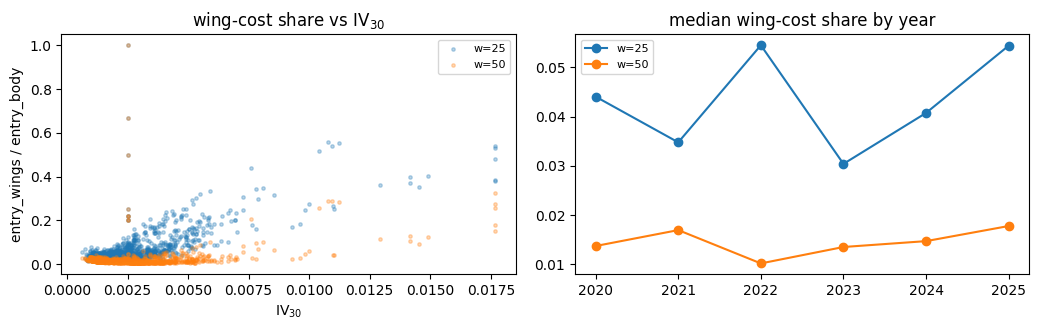

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\condor_lab_cum.png


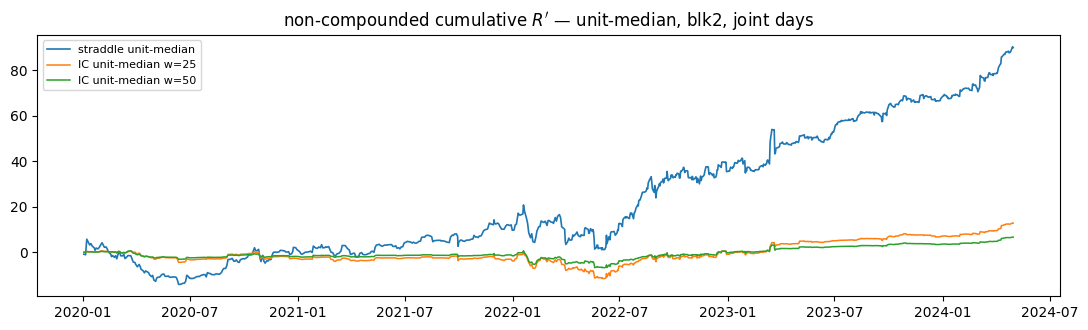

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
for w, ic in ics.items():
    axes[0].scatter(ic["iv_30"], ic["wing_share"], s=6, alpha=0.3, label=f"w={int(w)}")
axes[0].set_xlabel(r"$\mathrm{IV}_{30}$")
axes[0].set_ylabel("entry_wings / entry_body")
axes[0].set_title("wing-cost share vs $\\mathrm{IV}_{30}$")
axes[0].legend(fontsize=8)
for w, ic in ics.items():
    by_year = ic["wing_share"].groupby(ic.index.year).median()
    axes[1].plot(by_year.index, by_year.values, marker="o", label=f"w={int(w)}")
axes[1].set_title("median wing-cost share by year")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_diagnostics.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(joint, strad_um.loc[joint].cumsum().values, label="straddle unit-median", lw=1.2)
for w in ics:
    ax.plot(joint, cond_um[w].loc[joint].cumsum().values, label=f"IC unit-median w={int(w)}", lw=1.1)
ax.set_title("non-compounded cumulative $R'$ — unit-median, blk2, joint days")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_cum.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "condor_lab_cum.png")
display(fig)
plt.close(fig)


## 10. Strangle-body condors and per-side attribution

The defined-risk book (parked in the RV–IV deck, explored in §14) wraps the straddle-body
package in wings. Here the body is a **strangle**: the next listed strike above the
nearest-OTM call and below the nearest-OTM put, from the same 15:30
live mids (one step on the actual grid — $5$ points on $99.6\%$ of
days, never a fixed offset). Wings are `asl.pick_wings` measured from
the strangle legs, widths $25$ and $50$. Defined-risk return is
unchanged,
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply as-is; blk2 signal, common days.

**Per-side split** ($w=25$, unit-median $q$). Each side is its own
vertical: $R_{\mathrm{call}}=\big[(\mathrm{pay}_c-\mathrm{pay}_{cw})-(\mathrm{mid}_c-\mathrm{mid}_{cw})\big]/\mathrm{width}$,
same for the put side, so
$R_{\mathrm{call}}+R_{\mathrm{put}}=R_{\mathrm{long,ic}}$ exactly
(same denominator). $R'_{\mathrm{side}}=q\,R_{\mathrm{side}}$ answers
two questions: which spread earns the short-book mean, and which
spread bleeds on the worst-decile days.

In [12]:
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()
body_straddle = atm.reset_index()

def pick_strangle_body(live, atm_body):
    c = live[live["cp"] == "C"].copy()
    p = live[live["cp"] == "P"].copy()
    want = atm_body[["expiration", "day", "K_c", "K_p", "S"]].copy()
    c = c.merge(want[["expiration", "K_c"]], on="expiration", how="inner")
    p = p.merge(want[["expiration", "K_p"]], on="expiration", how="inner")
    c = c[c["strike"].astype(float) > c["K_c"]]
    p = p[p["strike"].astype(float) < p["K_p"]]
    c["k_gap"] = c["strike"].astype(float) - c["K_c"]
    p["k_gap"] = p["K_p"] - p["strike"].astype(float)
    c2 = c.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    p2 = p.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    legs = c2.merge(p2, on="expiration", suffixes=("_c", "_p"))
    out = want.merge(legs[["expiration", "strike_c", "strike_p", "mid_c", "mid_p"]],
                     on="expiration", how="inner", suffixes=("_atm", ""))
    out = out.rename(columns={"K_c": "K_c_atm", "K_p": "K_p_atm"})
    out["K_c"] = out["strike_c"].astype(float)
    out["K_p"] = out["strike_p"].astype(float)
    out["entry"] = out["mid_c"].astype(float) + out["mid_p"].astype(float)
    out["step_c"] = out["K_c"] - out["K_c_atm"]
    out["step_p"] = out["K_p_atm"] - out["K_p"]
    return out

body_strangle = pick_strangle_body(live, body_straddle)
print(f"strangle legs {len(body_strangle)} / body {len(body_straddle)}; "
      f"call step 5 on {float((body_strangle['step_c'] == 5).mean()):.1%} of days")

def score_ic(body, width, label):
    ic = asl.pick_wings(live, body, width=width)
    print(f"{label} width {width}: days with both wings {len(ic)} / body {len(body)}")
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    return ic.set_index("day").sort_index()

RULES = ["always short", "sign(s)", "unit-median VRP"]
KEEP = ["n", "mean", "t_mean", "Sharpe_ann", "pct_buy"]
sg_tabs, sg_frames = {}, {}
for label, body in (("straddle", body_straddle), ("strangle", body_strangle)):
    for w in (25.0, 50.0):
        ic = score_ic(body, w, label)
        joined = ic.join(books["blk2"][["signal", "pos", "R"]], how="inner", rsuffix="_strad")
        sizes = asl.rule_sizes(joined)
        common_ic = joined.index.intersection(common)
        tab = pd.DataFrame({
            name: asl.rule_row((sizes[name] * joined["R_long_ic"]).loc[common_ic],
                               sizes[name].loc[common_ic])
            for name in RULES
        }).T
        sg_tabs[(label, int(w))] = tab
        sg_frames[(label, int(w))] = (joined, sizes, common_ic)
        tab.to_csv(OUT / f"condor_lab_strangle_rules_{label}_w{int(w)}.csv")
for w in (25, 50):
    print(f"--- defined-risk R, blk2, width {w}: straddle vs strangle body ---")
    print(pd.concat({lb: sg_tabs[(lb, w)][KEEP] for lb in ("straddle", "strangle")},
                    names=["body", "rule"]).to_string())


strangle legs 1291 / body 1291; call step 5 on 99.6% of days


straddle width 25.0: days with both wings 1291 / body 1291


straddle width 50.0: days with both wings 1291 / body 1291


strangle width 25.0: days with both wings 1291 / body 1291


strangle width 50.0: days with both wings 1291 / body 1291
--- defined-risk R, blk2, width 25: straddle vs strangle body ---
                                   n      mean    t_mean  Sharpe_ann    pct_buy
body     rule                                                                  
straddle always short     871.000000  0.001076  0.133792    0.071965   0.000000
         sign(s)          871.000000  0.016519  2.058810    1.107408  38.920781
         unit-median VRP  871.000000  0.014626  1.030863    0.554488  38.920781
strangle always short     871.000000  0.005019  0.729201    0.392228   0.000000
         sign(s)          871.000000  0.013294  1.934850    1.040731  38.920781
         unit-median VRP  871.000000  0.012867  0.973115    0.523426  38.920781
--- defined-risk R, blk2, width 50: straddle vs strangle body ---
                                   n      mean    t_mean  Sharpe_ann    pct_buy
body     rule                                                                  
straddle 

per-side attribution, w=25, unit-median R'
                                     n      mean         t  share_of_total
body     side scope                                                       
straddle call all           871.000000  0.012067  0.910532        0.825013
              worst-decile   88.000000 -0.299439 -3.127772        0.381738
         put  all           871.000000  0.002559  0.183166        0.174987
              worst-decile   88.000000 -0.484971 -5.041375        0.618262
strangle call all           871.000000  0.008583  0.789074        0.667031
              worst-decile   88.000000 -0.306279 -3.775112        0.416870
         put  all           871.000000  0.004284  0.362610        0.332969
              worst-decile   88.000000 -0.428432 -4.972415        0.583130


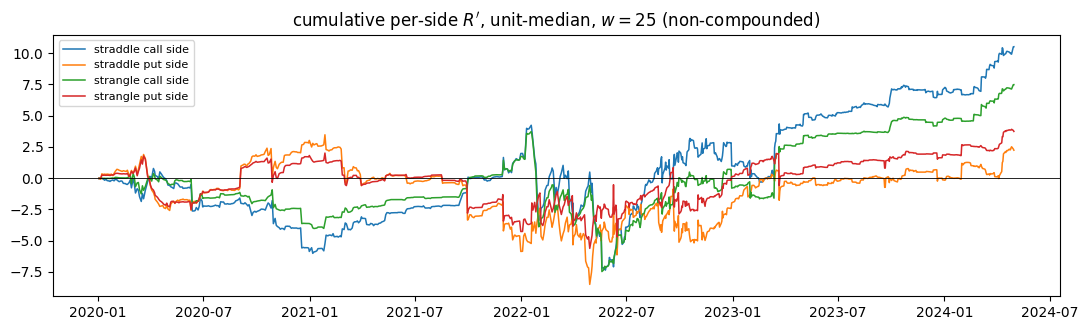

In [13]:
side_rows, side_cum = {}, {}
for label in ("straddle", "strangle"):
    joined, sizes, common_ic = sg_frames[(label, 25)]
    j = joined.loc[common_ic].copy()
    q = sizes["unit-median VRP"].loc[common_ic]
    j["R_call"] = ((j["pay_c"] - j["pay_c_wing"]) - (j["mid_c"].astype(float) - j["mid_c_wing"])) / j["width"]
    j["R_put"] = ((j["pay_p"] - j["pay_p_wing"]) - (j["mid_p"].astype(float) - j["mid_p_wing"])) / j["width"]
    assert (j["R_call"] + j["R_put"] - j["R_long_ic"]).abs().max() < 1e-10
    rp_tot = q * j["R_long_ic"]
    worst = rp_tot <= rp_tot.quantile(0.10)
    for side in ("R_call", "R_put"):
        rp = q * j[side]
        side_cum[(label, side)] = rp.cumsum()
        for scope, mask in (("all", rp_tot.notna()), ("worst-decile", worst)):
            x = rp[mask]
            mu, sd, n = float(x.mean()), float(x.std(ddof=1)), int(len(x))
            side_rows[(label, side.replace("R_", ""), scope)] = {
                "n": n, "mean": mu,
                "t": mu / sd * np.sqrt(n) if sd > 0 else np.nan,
                "share_of_total": mu / float(rp_tot[mask].mean()),
            }
side_tab = pd.DataFrame(side_rows).T
side_tab.index.names = ["body", "side", "scope"]
print("per-side attribution, w=25, unit-median R'")
print(side_tab.to_string())
side_tab.to_csv(OUT / "condor_lab_strangle_per_side_w25.csv")

fig, ax = plt.subplots(figsize=(11, 3.4))
for (label, side), cum in side_cum.items():
    ax.plot(cum.index, cum.values, lw=1.1,
            label=f"{label} {side.replace('R_', '')} side")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("cumulative per-side $R'$, unit-median, $w=25$ (non-compounded)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_strangle.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 11. Ensembles on the iron condor (defined-risk $R$)

One question: do the §5 ensemble positions transfer from the straddle
to the defined-risk condor instrument? The positions $q_t$ (mean-$s$
sign, majority vote, EW unit-median $q$, causal spectral PC1 sign /
unit-median, and the blk2 single-model benchmarks) are built once on
the common days exactly as in §5 and are not refit. Only the
instrument swaps: wings are the nearest live mids at least $w$ points
further OTM ($w=25,50$; the same wing selection as the credit-vertical
construction of §14) and
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply unchanged.

Each width prints two tables on the same day set $D_w$ (common days
with both wings): the condor book, and the same $q$ on the straddle
$R$. The mirror isolates instrument transfer from day-set drift; with
full wing coverage $D_w$ equals the common days and the drift is zero.

Caveats. Defined-risk $R$ divides by width, not premium: losses are
capped by construction and the denominator differs across instruments,
so Sharpe moves are partly tail/denominator effects, not signal
quality. The blk2 unit-median row uses §5's leverage (expanding median
on the common days). The defined-risk book, parked in the RV–IV deck, is scored per
body premium at $|q|=1$, so its rows are not in the same units as
these tables.

In [14]:
qs = {
    "mean-s then sign": np.sign(sig.mean(axis=1)).replace(0.0, -1.0),
    "majority vote": np.sign(pos.sum(axis=1)).replace(0.0, -1.0),
    "EW unit-median q": um.mean(axis=1),
    "spectral PC1 sign": q_pc1,
    "spectral PC1 unit-median": q_pc1_um,
    "blk2 unit-median": blk_sizes["unit-median VRP"].loc[common],
    "blk2 always short": pd.Series(-1.0, index=common),
}
body = atm.reset_index()
_exp = pd.to_datetime(atm["expiration"])
if getattr(_exp.dt, "tz", None) is not None:
    _exp = _exp.dt.tz_convert("America/New_York").dt.tz_localize(None)
close_map = pd.Series(atm["S_close"].to_numpy(), index=_exp.dt.normalize().values)

def bridge_table(r, D):
    return pd.DataFrame(
        {name: asl.rule_row(q.loc[D] * r.loc[D], q.loc[D]) for name, q in qs.items()}
    ).T

SHOW = ["n", "mean", "std", "t_mean", "Sharpe_ann", "pct_buy"]
tabs = {}
for w in (25.0, 50.0):
    ic = asl.pick_wings(live, body, width=w)
    n_wings = len(ic)
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic = ic.set_index("day")
    D = ic.index.intersection(common)
    print(f"width {int(w)}: both wings {n_wings} / {len(body)} body days; "
          f"scored D = common & coverage = {len(D)} / {len(common)} common")
    print(f"width {int(w)} frac entry_ic<=0 = {float((ic['entry_ic'] <= 0).mean()):.2%}")
    tabs[(int(w), "condor")] = bridge_table(ic["R_long_ic"], D)
    tabs[(int(w), "straddle same days")] = bridge_table(R, D)
    print(f"--- ensembles on iron condor w={int(w)}, defined-risk R ---")
    print(tabs[(int(w), "condor")][SHOW].to_string())
    print(f"--- same q on straddle R, same {len(D)} days ---")
    print(tabs[(int(w), "straddle same days")][SHOW].to_string())
pd.concat(tabs, names=["width", "instrument", "rule"]).to_csv(OUT / "condor_lab_ensemble.csv")
print("saved", OUT / "condor_lab_ensemble.csv")


width 25: both wings 1291 / 1291 body days; scored D = common & coverage = 871 / 871 common
width 25 frac entry_ic<=0 = 0.08%
--- ensembles on iron condor w=25, defined-risk R ---
                                   n      mean       std    t_mean  Sharpe_ann    pct_buy
mean-s then sign          871.000000  0.015383  0.236867  1.916709    1.030973  35.820896
majority vote             871.000000  0.015370  0.236868  1.915034    1.030072  35.476464
EW unit-median q          871.000000  0.016256  0.391116  1.226611    0.659778  36.165327
spectral PC1 sign         871.000000  0.012175  0.237054  1.515762    0.815309  23.880597
spectral PC1 unit-median  871.000000 -0.001507  0.289286 -0.153734   -0.082692  23.880597
blk2 unit-median          871.000000  0.014626  0.418726  1.030863    0.554488  38.920781
blk2 always short         871.000000  0.001076  0.237364  0.133792    0.071965   0.000000
--- same q on straddle R, same 871 days ---
                                   n      mean       std

width 50: both wings 1291 / 1291 body days; scored D = common & coverage = 871 / 871 common
width 50 frac entry_ic<=0 = 0.08%
--- ensembles on iron condor w=50, defined-risk R ---
                                   n      mean       std    t_mean  Sharpe_ann    pct_buy
mean-s then sign          871.000000  0.009084  0.140651  1.906058    1.025244  35.820896
majority vote             871.000000  0.009104  0.140649  1.910212    1.027478  35.476464
EW unit-median q          871.000000  0.011531  0.234125  1.453485    0.781811  36.165327
spectral PC1 sign         871.000000  0.007308  0.140754  1.532379    0.824247  23.880597
spectral PC1 unit-median  871.000000  0.001789  0.185483  0.284694    0.153133  23.880597
blk2 unit-median          871.000000  0.007542  0.260284  0.855158    0.459979  38.920781
blk2 always short         871.000000  0.000978  0.140941  0.204774    0.110145   0.000000
--- same q on straddle R, same 871 days ---
                                   n      mean       std

## 12. Fill sensitivity (quoted-spread $\lambda$-fills)

A condor has four legs, a straddle two: quoted-spread cost is the
standing objection to any condor result. Fill model, per leg,

$$\mathrm{fill} = \mathrm{mid} + \sigma\,\lambda\,\tfrac{\mathrm{ask}-\mathrm{bid}}{2},
\qquad \sigma=+1\ \text{bought},\ \sigma=-1\ \text{sold},\qquad
\lambda\in\{0,\tfrac12,1\}.$$

$\lambda=0$ is the mid-fill book; $\lambda=1$ fills every short leg at
the bid and every long leg at the ask (the lib's
`crossed_premium_return` at the straddle). Exit is cash settlement at
the official close — no exit spread. The signal $s$ is untouched:
fills change $R$, not $s$, so positions are identical across
$\lambda$ and the tables isolate pure fill cost. Straddle $R$ keeps
the entry denominator (now the filled entry); condor $R$ keeps the
width denominator, so its cost enters linearly:
$R'=qR_{\mathrm{long,ic}} - |q|\,\lambda\,H/\mathrm{width}$ with $H$
the sum of the four half-spreads.

Quote hygiene: sold legs require $\mathrm{bid}>0$; bought wing legs
allow a zero bid (a legitimate deep-OTM quote state — the buy fills at
the ask side). Zero-bid wings are the norm, not the exception (w=50
call wing: bid $\le 0$ on 783 of 871 days), which is exactly why wing
spreads are proportionally enormous while body spreads are tight. The
scored set is the quoted subset of the common days (867 of 871); the
$\lambda=0$ rows therefore differ slightly from the §5/§7 tables — the
four dropped days were profitable shorts.

$\lambda=1$ is a worst-case quoted fill, not a market-impact model;
real fills on a four-leg package sit between the marks.

hygiene body call      n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene body put       n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
straddle: common=871 scored=867
--- straddle, lambda-fill, blk2 ---
                                  n      mean    t_mean  Sharpe_ann
lam=0.0 always short     867.000000  0.015612  0.407718    0.219812
        unit-median VRP  867.000000  0.092229  2.172740    1.171382
lam=0.5 always short     867.000000 -0.001348 -0.034549   -0.018626
        unit-median VRP  867.000000  0.077059  1.809566    0.975585
lam=1.0 always short     867.000000 -0.019103 -0.480457   -0.259027
        unit-median VRP  867.000000  0.061729  1.443711    0.778343


width 25.0: days with both wings 1291 / body 1291
hygiene body C (w25)   n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene body P (w25)   n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene wing C (w25)   n=871 missing=0 bid<=0=421 crossed=0 usable=871 (strict bid>0: 450)
hygiene wing P (w25)   n=871 missing=0 bid<=0=128 crossed=0 usable=871 (strict bid>0: 743)
condor w25: scored=867
--- iron condor w=25, defined-risk R, lambda-fill, blk2 ---
                                  n      mean    t_mean  Sharpe_ann
lam=0.0 always short     867.000000  0.001064  0.131650    0.070976
        unit-median VRP  867.000000  0.014650  1.027843    0.554138
lam=0.5 always short     867.000000 -0.005517 -0.679574   -0.366376
        unit-median VRP  867.000000  0.006505  0.454824    0.245208
lam=1.0 always short     867.000000 -0.012097 -1.478608   -0.797157
        unit-median VRP  867.000000 -0.001640 -0.114106   -0.061517


width 50.0: days with both wings 1291 / body 1291
hygiene body C (w50)   n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene body P (w50)   n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene wing C (w50)   n=871 missing=0 bid<=0=783 crossed=0 usable=871 (strict bid>0: 88)
hygiene wing P (w50)   n=871 missing=0 bid<=0=592 crossed=0 usable=871 (strict bid>0: 279)
condor w50: scored=867
--- iron condor w=50, defined-risk R, lambda-fill, blk2 ---
                                  n      mean    t_mean  Sharpe_ann
lam=0.0 always short     867.000000  0.000974  0.202970    0.109427
        unit-median VRP  867.000000  0.007555  0.852728    0.459728
lam=0.5 always short     867.000000 -0.002070 -0.428247   -0.230880
        unit-median VRP  867.000000  0.003844  0.432788    0.233328
lam=1.0 always short     867.000000 -0.005114 -1.048186   -0.565105
        unit-median VRP  867.000000  0.000132  0.014822    0.007991
--- Sharpe erosion: Sharpe(lam=1

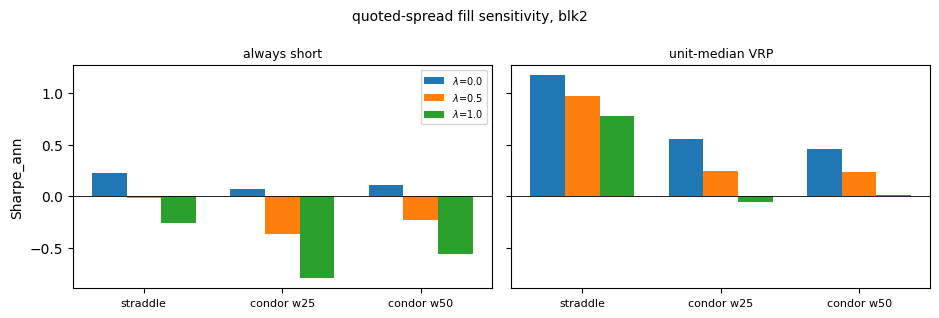

In [15]:
def _tc_leg_ok(bid, ask, sold):
    b = pd.to_numeric(bid, errors="coerce")
    a = pd.to_numeric(ask, errors="coerce")
    base = np.isfinite(b) & np.isfinite(a) & (a >= b) & (b >= 0)
    return base & (b > 0) if sold else base

def _tc_hygiene(df, b, a, label, sold):
    bb, aa = pd.to_numeric(df[b], errors="coerce"), pd.to_numeric(df[a], errors="coerce")
    ok = _tc_leg_ok(bb, aa, sold)
    print(f"hygiene {label:14s} n={len(df)} missing={int((~np.isfinite(bb) | ~np.isfinite(aa)).sum())} "
          f"bid<=0={int((np.isfinite(bb) & (bb <= 0)).sum())} "
          f"crossed={int((np.isfinite(bb) & np.isfinite(aa) & (bb > aa)).sum())} "
          f"usable={int(ok.sum())} (strict bid>0: {int(_tc_leg_ok(bb, aa, True).sum())})")
    return ok

px = books["blk2"]
tc_sizes = asl.rule_sizes(px)
TC_RULES = ["always short", "unit-median VRP"]
TC_LAMS = [0.0, 0.5, 1.0]

ok_c = _tc_hygiene(px, "bid_c", "ask_c", "body call", sold=True)
ok_p = _tc_hygiene(px, "bid_p", "ask_p", "body put", sold=True)
idx_s = common.intersection(px.index[ok_c & ok_p])
print(f"straddle: common={len(common)} scored={len(idx_s)}")
h_strad = (px["ask_c"] - px["bid_c"]) / 2.0 + (px["ask_p"] - px["bid_p"]) / 2.0
tc_spreads = {
    "body call": float(((px["ask_c"] - px["bid_c"]) / px["mid_c"]).loc[idx_s].median()),
    "body put": float(((px["ask_p"] - px["bid_p"]) / px["mid_p"]).loc[idx_s].median()),
}
rows = {}
for lam in TC_LAMS:
    for rule in TC_RULES:
        q = tc_sizes[rule]
        entry_fill = px["entry"] + np.sign(q) * lam * h_strad
        rp = q * (px["exit"] / entry_fill - 1.0)
        rows[(f"lam={lam}", rule)] = asl.rule_row(rp.loc[idx_s], q.loc[idx_s])
tc_tabs = {"straddle": pd.DataFrame(rows).T[["n", "mean", "t_mean", "Sharpe_ann"]]}
print("--- straddle, lambda-fill, blk2 ---")
print(tc_tabs["straddle"].to_string())
tc_tabs["straddle"].to_csv(OUT / "condor_lab_tcost_straddle.csv")

tc_body = atm.reset_index()
tc_close = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
tc_close.index = pd.to_datetime(tc_close.index).tz_localize(None).normalize()
for w in (25.0, 50.0):
    ic = asl.pick_wings(live, tc_body, width=w)
    print(f"width {w}: days with both wings {len(ic)} / body {len(tc_body)}")
    ic = asl.settle_package(ic, tc_close)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].set_index("day")
    joined = ic.join(px[["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sz = asl.rule_sizes(joined)
    oks = (_tc_hygiene(joined, "bid_c", "ask_c", f"body C (w{int(w)})", sold=True)
           & _tc_hygiene(joined, "bid_p", "ask_p", f"body P (w{int(w)})", sold=True)
           & _tc_hygiene(joined, "bid_cw", "ask_cw", f"wing C (w{int(w)})", sold=False)
           & _tc_hygiene(joined, "bid_pw", "ask_pw", f"wing P (w{int(w)})", sold=False))
    idx = joined.index[oks].intersection(common)
    print(f"condor w{int(w)}: scored={len(idx)}")
    h_tot = ((joined["ask_c"] - joined["bid_c"]) + (joined["ask_p"] - joined["bid_p"])
             + (joined["ask_cw"] - joined["bid_cw"]) + (joined["ask_pw"] - joined["bid_pw"])) / 2.0
    tc_spreads[f"wing call w{int(w)}"] = float(((joined["ask_cw"] - joined["bid_cw"]) / joined["mid_c_wing"]).loc[idx].median())
    tc_spreads[f"wing put w{int(w)}"] = float(((joined["ask_pw"] - joined["bid_pw"]) / joined["mid_p_wing"]).loc[idx].median())
    base = (joined["exit_ic"] - joined["entry_ic"]) / joined["width"]
    rows = {}
    for lam in TC_LAMS:
        for rule in TC_RULES:
            q = sz[rule]
            rp = q * base - q.abs() * lam * h_tot / joined["width"]
            rows[(f"lam={lam}", rule)] = asl.rule_row(rp.loc[idx], q.loc[idx])
    tab = pd.DataFrame(rows).T[["n", "mean", "t_mean", "Sharpe_ann"]]
    print(f"--- iron condor w={int(w)}, defined-risk R, lambda-fill, blk2 ---")
    print(tab.to_string())
    tab.to_csv(OUT / f"condor_lab_tcost_w{int(w)}.csv")
    tc_tabs[f"condor w{int(w)}"] = tab

tc_ero = pd.Series({(inst, rule): tab.loc[("lam=1.0", rule), "Sharpe_ann"] - tab.loc[("lam=0.0", rule), "Sharpe_ann"]
                    for inst, tab in tc_tabs.items() for rule in TC_RULES}).unstack()
print("--- Sharpe erosion: Sharpe(lam=1) - Sharpe(lam=0) ---")
print(tc_ero.to_string())
tc_ero.to_csv(OUT / "condor_lab_tcost_erosion.csv")
tc_sp = pd.Series(tc_spreads, name="median (ask-bid)/mid")
print("--- median relative spread by leg class ---")
print(tc_sp.to_string())
tc_sp.to_csv(OUT / "condor_lab_tcost_spreads.csv")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
xs = np.arange(len(tc_tabs))
for ax, rule in zip(axes, TC_RULES):
    for j, lam in enumerate(TC_LAMS):
        ys = [tc_tabs[k].loc[(f"lam={lam}", rule), "Sharpe_ann"] for k in tc_tabs]
        ax.bar(xs + (j - 1) * 0.25, ys, width=0.25, label=f"$\\lambda$={lam}")
    ax.set_xticks(xs)
    ax.set_xticklabels(list(tc_tabs), fontsize=8)
    ax.set_title(rule, fontsize=9)
    ax.axhline(0, color="k", lw=0.6)
axes[0].set_ylabel("Sharpe_ann")
axes[0].legend(fontsize=7)
fig.suptitle("quoted-spread fill sensitivity, blk2", fontsize=10)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_tcost.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 13. Paired significance on the headline deltas

The `rule_row` $t$'s test each book's mean against zero. The questions
that matter are *differences*: does book $A$ beat book $B$ on the same
days? Let $d_t = R'^{A}_t - R'^{B}_t$ on the common days of the pair.
Two tests, both stated once and applied to every pair:

- **Newey–West:** $t = \bar d / \widehat{\mathrm{se}}_{NW}(\bar d)$
  with Bartlett kernel and lag $L=\lfloor 1.5\,n^{1/3}\rfloor$.
- **Circular moving-block bootstrap:** block length
  $b=\lceil n^{1/3}\rceil$, $B=2000$, seed $0$, resampling the pair
  jointly. 95% percentile CI on $\bar d$ and on
  $\Delta\mathrm{Sharpe}_{ann}$ (both books' Sharpes recomputed per
  resample, then differenced).

Pairs: (a) condor $w{=}25$ unit-median vs straddle unit-median, same
blk2 $q_t$ both legs (the published straddle-book sizes restricted to
condor days — leverage is *not* refit on the condor subset); (b)
spectral PC1 unit-median vs blk2 unit-median; (c) EW unit-median $q$
vs blk2 unit-median; (d) blk2 unit-median vs always short.

Caveats. In (a) the two returns sit on different denominators
(straddle entry vs condor width), so $\bar d$ is a bookkeeping
comparison of the published book definitions; $\Delta$Sharpe is the
scale-free column. A null here is the expected outcome — nothing in
this lab has beaten blk2 unit-median — these rows say whether the
*gaps* in the ensemble table are distinguishable from noise at all.
`mean_delta_bp` is $\bar d\times 10^4$ per day; `sig_*` flags are 5%
two-sided.

In [16]:
def _nw_t(d):
    n_ = len(d)
    L = int(np.floor(1.5 * n_ ** (1.0 / 3.0)))
    dc = d - d.mean()
    v = float(dc @ dc) / n_
    for lag in range(1, L + 1):
        v += 2.0 * (1.0 - lag / (L + 1.0)) * float(dc[lag:] @ dc[:-lag]) / n_
    return float(d.mean() / np.sqrt(v / n_)), L

def _cmb_idx(n_, B, rng):
    b = int(np.ceil(n_ ** (1.0 / 3.0)))
    nb = int(np.ceil(n_ / b))
    starts = rng.integers(0, n_, size=(B, nb))
    return ((starts[:, :, None] + np.arange(b)[None, None, :]) % n_).reshape(B, nb * b)[:, :n_]

def _sharpe(a, axis=None):
    return a.mean(axis=axis) / a.std(axis=axis, ddof=1) * np.sqrt(252.0)

def pair_row(name, rp, rb, B=2000):
    a = rp.align(rb, join="inner")
    x = a[0].dropna()
    y = a[1].reindex(x.index)
    x, y = x.to_numpy(float), y.to_numpy(float)
    d = x - y
    n_ = len(d)
    t_nw, L = _nw_t(d)
    idx = _cmb_idx(n_, B, np.random.default_rng(0))
    dm = d[idx].mean(axis=1)
    lo_m, hi_m = np.percentile(dm, [2.5, 97.5])
    ds = _sharpe(x[idx], axis=1) - _sharpe(y[idx], axis=1)
    lo_s, hi_s = np.percentile(ds, [2.5, 97.5])
    return {
        "pair": name, "n": n_, "nw_lag": L,
        "block_len": int(np.ceil(n_ ** (1.0 / 3.0))),
        "mean_delta_bp": d.mean() * 1e4, "NW_t": t_nw,
        "boot_lo_bp": lo_m * 1e4, "boot_hi_bp": hi_m * 1e4,
        "dSharpe_ann": _sharpe(x) - _sharpe(y), "dS_lo": lo_s, "dS_hi": hi_s,
        "sig_NW": abs(t_nw) > 1.96,
        "sig_boot_mean": (lo_m > 0) or (hi_m < 0),
        "sig_boot_dS": (lo_s > 0) or (hi_s < 0),
    }

# condor w=25, credit-vertical wing conventions (asl.pick_wings); blk2 straddle-book UM sizes on both legs
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()
ic25 = asl.pick_wings(live, body, width=25.0)
ic25 = asl.settle_package(ic25, close_map)
ic25 = ic25[np.isfinite(ic25["entry_ic"]) & np.isfinite(ic25["exit_ic"]) & (ic25["width"] > 0)].copy()
ic25["R_long_ic"] = (ic25["exit_ic"] - ic25["entry_ic"]) / ic25["width"]
ic25 = ic25.set_index("day")
common_ic = ic25.index.intersection(common).sort_values()
um_blk2 = blk_sizes["unit-median VRP"]
r_ic_um = um_blk2.loc[common_ic] * ic25["R_long_ic"].loc[common_ic]
print("condor w25 coverage on common days", len(common_ic), "/", len(common))

sig_tab = pd.DataFrame([
    pair_row("condor25 UM - straddle UM (blk2)", r_ic_um, ens["blk2 unit-median (bench)"].loc[common_ic]),
    pair_row("PC1 UM - blk2 UM", ens["spectral PC1 unit-median"], ens["blk2 unit-median (bench)"]),
    pair_row("EW um q - blk2 UM", ens["EW unit-median q"], ens["blk2 unit-median (bench)"]),
    pair_row("blk2 UM - always short", ens["blk2 unit-median (bench)"], ens["always short"]),
]).set_index("pair")
print(sig_tab.to_string(float_format=lambda v: f"{v: .3f}"))
sig_tab.to_csv(OUT / "significance_pairs.csv")
print("saved", OUT / "significance_pairs.csv")


condor w25 coverage on common days 871 / 871


                                    n  nw_lag  block_len  mean_delta_bp   NW_t  boot_lo_bp  boot_hi_bp  dSharpe_ann  dS_lo  dS_hi  sig_NW  sig_boot_mean  sig_boot_dS
pair                                                                                                                                                                 
condor25 UM - straddle UM (blk2)  871      14         10       -887.260 -3.451   -1459.513    -335.953       -0.750 -1.267 -0.232    True           True         True
PC1 UM - blk2 UM                  871      14         10       -693.637 -2.721   -1251.765    -155.249       -0.704 -1.519  0.097    True           True        False
EW um q - blk2 UM                 871      14         10         76.246  0.539    -202.319     380.208        0.294 -0.106  0.722   False          False        False
blk2 UM - always short            871      14         10        832.194  1.832    -184.884    1839.909        1.020 -0.389  2.328   False          False        False
save

## 14. Why the iron-fly wings do not pay per premium

A defined-risk version of the book, parked in the main notebook and explored here, wraps it in an iron fly — a wing bought
on each side of the body whenever the book sells, which turns the
short straddle into two credit spreads — and keeps it as a venue
constraint, the defined-risk structure a retail margin account
requires on cash-settled SPX or XSP, not as an improvement. Per dollar
of body premium the wings do not help: the $\mathrm{sign}(s)$
book loses Sharpe (1.42 with wings 25 points out and 1.54 at 50 points,
against 1.62 without wings on the same days), the always-short control
loses what little edge it had, and compounded wealth suffers in
proportion. The only frame in which the wings look free is index
points per package, where they cost 0.007 points a day on average with
a paired $t$-statistic of essentially zero. This section asks why, so
that the construction can be revisited with the right question rather
than dropped.

The book is rebuilt here exactly as the parked deck section built it. The
body is the 15:30 nearest-out-of-the-money package; the wings are the
nearest live 15:30 midpoint quotes at least $w$ points further out of
the money; the package is settled in cash at the official close; the
net credit is body premium minus wing premium, and days with a
non-positive credit are dropped with a printed count; the seller's
worst case is the larger actual wing gap minus the credit. Returns are
per dollar of body premium throughout, on the same days and with the
same denominator for the hedged and the plain book, so every
comparison is like against like. The cell first reproduces the parked section's
headline at 25 points and stops if it cannot.

Four questions follow.

1. *Where does the wing cost come from?* For each year, the premium
   paid for the wings on an average day against what they pay back at
   settlement, and how much of the payback arrives on the few days the
   settlement lands beyond a wing. The accounting is repeated with the
   body sold at the bid and the wings bought at the ask, because deep
   out-of-the-money wings are quoted with very wide spreads relative to
   their price.
2. *Does one wing do the work?* The crash tail of an index is
   asymmetric, so the put wing alone and the call wing alone are scored
   against both wings and none.
3. *Is there a width at which the hedged book wins?* The width ladder
   of §8 — fixed gaps of 10 to 100 points, including the 20- and
   30-point wings the parked section reported, and gaps scaled to the package price —
   scored per premium on the $\mathrm{sign}(s)$ composite,
   with the share of selling days on which the settlement reaches a
   wing.
4. *When do the wings pay?* The distribution of how far the settlement
   travels from the body strike, in units of the wing gap, and the
   per-year Sharpe ratios of the hedged and plain books, to see whether
   the wings earn their keep only in the crash year.

**What the exploration shows.** The wings do not pay per dollar of
premium in any configuration tried, and the tables say why. The cost
is not the midpoint premium: at midpoint quotes the wings roughly pay
for themselves over the whole sample. It is concentration. Essentially
all of the payback arrived in 2020 — at 25 points, 249 of the 398
points ever returned beyond a wing, and a net gain of 152 points that
year against a net cost in every year since — so the "free insurance"
is one crash quarter's payouts spread over four years of premium, and
that quarter sits inside the first 64 sessions that the main deck's
other slides exclude as their estimation window. On the days that
matter for the $\mathrm{sign}(s)$ book the settlement rarely travels far: on
selling days the median settlement sits a sixth of the way from the
body strike to a 25-point wing, and reaches the wing on 4.3% of them
(1.1% at 50 points). The wing that protects is the expensive one: the
put wing alone costs almost as much Sharpe as both wings and is the
only one that shortens the worst day, while the call wing is nearly
free and protects nothing. No width on the ladder beats the plain book
— the best is 50 points, 0.08 of Sharpe behind with a paired $t$ of
$-2.2$ — and the gap is negative for all seven forecasts. At the 20-
and 30-point wings the parked section reported, the $\mathrm{sign}(s)$ book gives up 0.26 and
0.15 of Sharpe (paired $t$ of $-2.8$ and $-2.1$) and the settlement
reaches a wing on 7.3% and 2.4% of selling days. Paying the quoted
spread makes it worse: with the wings bought at the ask, which is
quoted at 1.2 to 2 times their midpoint, they cost 0.09 points a
day and the $\mathrm{sign}(s)$ book gives up 0.3 of Sharpe at 25 points
against the plain book filled the same way.

**What the construction still owes**, as questions rather than claims.
Would wings placed by delta, or by the forecast itself — wider when
the forecast is calm, tighter when it is not — change the ratio of
cost to coverage, given that the cap is reached on one selling day in
twenty-five? Would hedging conditionally, only on days some measure
flags elevated risk, buy the protection where it is cheap relative to
the payoff? (§15 tries the lagged signal's rank as that measure and
finds it points at the wrong tail.) And is the crash-year payoff a property of the instrument or
of one event?

gate: w=25 sign(s) per premium, hedged Sharpe 1.4169 (RV-IV section 16 at w=25: 1.417); wing cost all days -0.0067 pts/day (RV-IV section 16: -0.007)
gate passed
=== (a) wing premium paid vs wing settlement received, index points per package ===
                                 days  wing_premium_paid  wing_settlement_received  net_cost  days_beyond_wing  pts_returned_on_those_days
w  frame                   year                                                                                                           
25 all days (always short) all    870              0.666                     0.673    -0.007                35                     397.975
                           2020   160              1.440                     2.388    -0.948                12                     248.560
                           2021   158              0.307                     0.150     0.157                 5                      17.400
                           2022   220              1.044   

                       Sharpe_hedged  Sharpe_plain  NW_t_diff  worst_hedged  wing_cost_pts_per_sell_day  pct_sell_days_beyond_wing
w  wings rule                                                                                                                     
20 none  always short          0.268         0.268      0.040       -10.316                       0.000                      0.000
         sign(s)               1.617         1.617      0.470        -5.422                       0.000                      0.000
   put   always short         -0.062         0.268     -2.843        -6.852                       0.134                      3.448
         sign(s)               1.398         1.617     -3.204        -5.444                       0.134                      3.766
   call  always short          0.196         0.268     -0.673       -10.324                      -0.099                      3.218
         sign(s)               1.580         1.617     -0.831        -4.655        

                             n  med_gap  Sharpe_hedged  Sharpe_plain  dSharpe  NW_t_diff  worst_hedged  worst_plain  wing_cost_pts_per_sell_day  pct_sell_days_beyond_wing
width    rule                                                                                                                                                             
w10      always short  870.000   10.000         -0.339         0.268   -0.607     -1.789        -5.656      -10.316                       0.070                     22.184
         sign(s)       870.000   10.000          1.190         1.617   -0.426     -3.028        -3.881       -5.422                       0.135                     23.352
w20      always short  870.000   20.000         -0.154         0.268   -0.421     -2.443        -6.869      -10.316                       0.036                      6.667
         sign(s)       870.000   20.000          1.361         1.617   -0.256     -2.800        -4.676       -5.422                      -0.003  

                                 Sharpe_hedged  Sharpe_plain  dSharpe  NW_t_diff  worst_hedged  worst_plain
model                        w                                                                             
HAR + calendar OLS           25          0.700         0.982   -0.282     -3.698        -5.437       -5.422
                             50          0.871         0.982   -0.111     -3.289        -5.437       -5.422
block-diag ridge             25          1.417         1.617   -0.200     -2.496        -5.437       -5.422
                             50          1.539         1.617   -0.077     -2.180        -5.437       -5.422
LightGBM                     25          1.025         1.317   -0.292     -3.312        -5.437       -5.422
                             50          1.198         1.317   -0.120     -3.502        -5.437       -5.422
XGBoost                      25          1.033         1.373   -0.341     -5.820        -5.437       -5.422
                            

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\vert_lab_width_ladder.png


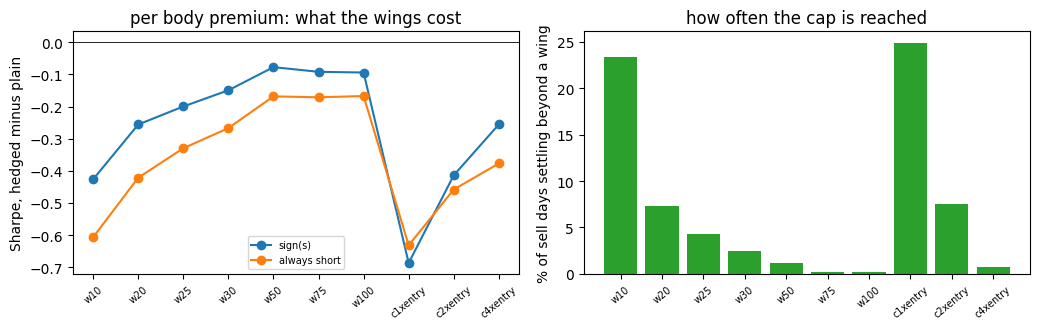

In [17]:
# --- the iron-fly book, rebuilt exactly as the parked RV-IV deck section built it ---
vl_body = atm.reset_index()
vl_close = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
vl_close.index = pd.to_datetime(vl_close.index).tz_localize(None).normalize()

def vl_settle(raw):
    vs = asl.settle_package(raw, vl_close)
    vs = vs[np.isfinite(vs["entry_ic"]) & np.isfinite(vs["exit_ic"]) & (vs["width"] > 0)].copy()
    vs["credit"] = vs["entry_ic"]
    vs["gap_c"] = vs["K_c_wing"] - vs["K_c"]
    vs["gap_p"] = vs["K_p"] - vs["K_p_wing"]
    vs["gap_max"] = np.maximum(vs["gap_c"], vs["gap_p"])
    vs = vs[(vs["credit"] > 0) & (vs["credit"] < vs["gap_max"])].copy()
    # package P&L in index points for a seller, four wing configurations
    vs["pnl_none"] = vs["entry_body"] - vs["exit"]
    vs["pnl_both"] = vs["credit"] - vs["exit_ic"]
    vs["pnl_put"] = (vs["entry_body"] - vs["mid_p_wing"]) - (vs["exit"] - vs["pay_p_wing"])
    vs["pnl_call"] = (vs["entry_body"] - vs["mid_c_wing"]) - (vs["exit"] - vs["pay_c_wing"])
    # what each wing costs net of what it pays back (positive = the wing cost money that day)
    vs["drag_both"] = vs["entry_wings"] - vs["exit_wings"]
    vs["drag_put"] = vs["mid_p_wing"] - vs["pay_p_wing"]
    vs["drag_call"] = vs["mid_c_wing"] - vs["pay_c_wing"]
    vs["drag_none"] = 0.0
    vs["beyond_call"] = vs["S_close"] >= vs["K_c_wing"]
    vs["beyond_put"] = vs["S_close"] <= vs["K_p_wing"]
    vs["beyond_both"] = vs["beyond_call"] | vs["beyond_put"]
    vs["beyond_none"] = False
    # settlement distance from the body strike, in units of the wing gap on that side (0 inside the body)
    up = (vs["S_close"] - vs["K_c"]) / vs["gap_c"]
    dn = (vs["K_p"] - vs["S_close"]) / vs["gap_p"]
    vs["dist_gap"] = np.maximum(np.maximum(up, dn), 0.0)
    return vs.set_index("day").sort_index()

def vl_book(width=None, w_row=None):
    raw = asl.pick_wings(live, vl_body, width=width) if w_row is None else pick_wings_perday(live, vl_body, w_row)
    return vl_settle(raw)

def vl_rows(vs, px, cfg="both"):
    # per-premium rows for the two rules; the hedged book against the plain book on the same days
    j = vs.join(px[["pos", "R"]], how="inner", rsuffix="_strad")
    j = j.loc[j.index.intersection(common)]
    hedged = j[f"pnl_{cfg}"] / j["entry_body"]
    out = {}
    for name, h, plain, sell in (
        ("always short", hedged, -j["R"], pd.Series(True, index=j.index)),
        ("sign(s)", hedged.where(j["pos"] < 0, j["R"]), j["pos"] * j["R"], j["pos"] < 0),
    ):
        t_nw, _ = _nw_t((h - plain).to_numpy(float))
        out[name] = pd.Series({
            "n": len(j),
            "Sharpe_hedged": _sharpe(h), "Sharpe_plain": _sharpe(plain), "dSharpe": _sharpe(h) - _sharpe(plain),
            "NW_t_diff": t_nw,
            "worst_hedged": float(h.min()), "worst_plain": float(plain.min()),
            "wing_cost_pts_per_sell_day": float(j.loc[sell, f"drag_{cfg}"].mean()),
            "pct_sell_days_beyond_wing": 100.0 * float(j.loc[sell, f"beyond_{cfg}"].mean()),
        })
    return pd.DataFrame(out).T, j

px_b = books["blk2"]
vl = {w: vl_book(width=w) for w in (25.0, 50.0)}
# the wing widths the RV-IV deck section 16 reports, for the fills and one-sided tables
vl_wide = {w: (vl[w] if w in vl else vl_book(width=w)) for w in (20.0, 25.0, 30.0, 50.0)}

# --- gate: reproduce the RV-IV section 16 headline before extending ---
rows25, j25 = vl_rows(vl[25.0], px_b)
print("gate: w=25 sign(s) per premium, hedged Sharpe", f"{rows25.loc['sign(s)', 'Sharpe_hedged']:.4f}",
      "(RV-IV section 16 at w=25: 1.417); wing cost all days", f"{float(j25['drag_both'].mean()):+.4f} pts/day (RV-IV section 16: -0.007)")
assert abs(rows25.loc["sign(s)", "Sharpe_hedged"] - 1.417) < 0.005
assert abs(float(j25["drag_both"].mean()) - (-0.007)) < 0.002
print("gate passed")

# (a) where the wing cost comes from: premium paid vs settlement received, by year
print("=== (a) wing premium paid vs wing settlement received, index points per package ===")
dec_rows = []
for w, vs in vl.items():
    j = vs.join(px_b[["pos", "R"]], how="inner", rsuffix="_strad")
    j = j.loc[j.index.intersection(common)]
    for frame, mask in (("all days (always short)", pd.Series(True, index=j.index)), ("sell days (sign(s))", j["pos"] < 0)):
        g = j.loc[mask]
        for yr, gy in [("all", g)] + list(g.groupby(g.index.year)):
            dec_rows.append({
                "w": int(w), "frame": frame, "year": yr, "days": len(gy),
                "wing_premium_paid": float(gy["entry_wings"].mean()),
                "wing_settlement_received": float(gy["exit_wings"].mean()),
                "net_cost": float(gy["drag_both"].mean()),
                "days_beyond_wing": int(gy["beyond_both"].sum()),
                "pts_returned_on_those_days": float((gy["exit_wings"] - gy["entry_wings"])[gy["beyond_both"]].sum()),
            })
vl_dec = pd.DataFrame(dec_rows).set_index(["w", "frame", "year"])
print(vl_dec.to_string(float_format=lambda v: f"{v: .3f}"))
vl_dec.to_csv(OUT / "vert_lab_wing_cost_by_year_blk2.csv")

# (a2) realistic fills: body sold at the bid, wings bought at the ask; buy days pay the ask on the body
print("=== (a2) paying the quoted spread: body at the bid, wings at the ask ===")
fill_rows = []
for w, vs in vl_wide.items():
    j = vs.join(px_b[["pos", "R"]], how="inner", rsuffix="_strad")
    j = j.loc[j.index.intersection(common)]
    ok = (_tc_leg_ok(j["bid_c"], j["ask_c"], True) & _tc_leg_ok(j["bid_p"], j["ask_p"], True)
          & _tc_leg_ok(j["bid_cw"], j["ask_cw"], False) & _tc_leg_ok(j["bid_pw"], j["ask_pw"], False))
    j = j.loc[ok]
    body_bid = j["bid_c"].astype(float) + j["bid_p"].astype(float)
    body_ask = j["ask_c"].astype(float) + j["ask_p"].astype(float)
    wings_ask = j["ask_cw"].astype(float) + j["ask_pw"].astype(float)
    denom = j["entry_body"]  # the mid premium stays the unit; only the fills move
    sell = j["pos"] < 0
    books_x = {
        "mid, plain": (j["pnl_none"] / denom, (j["exit"] - j["entry_body"]) / denom),
        "mid, wings": (j["pnl_both"] / denom, (j["exit"] - j["entry_body"]) / denom),
        "spread, plain": ((body_bid - j["exit"]) / denom, (j["exit"] - body_ask) / denom),
        "spread, wings": ((body_bid - wings_ask - j["exit_ic"]) / denom, (j["exit"] - body_ask) / denom),
    }
    drag_x = wings_ask - j["exit_wings"]
    for label, (short_leg, long_leg) in books_x.items():
        as_ = short_leg
        ls = short_leg.where(sell, long_leg)
        fill_rows.append({"w": int(w), "fill": label, "days": len(j),
                          "Sharpe_always_short": _sharpe(as_), "Sharpe_sign_s": _sharpe(ls),
                          "worst_sign_s": float(ls.min())})
    t_mid, _ = _nw_t(j["drag_both"].to_numpy(float))
    t_x, _ = _nw_t(drag_x.to_numpy(float))
    print(f"w={int(w)}: wing cost at mid {float(j['drag_both'].mean()):+.3f} pts/day (NW t {t_mid:+.2f}); "
          f"wings at the ask {float(drag_x.mean()):+.3f} pts/day (NW t {t_x:+.2f}); "
          f"median wing ask/mid {float((wings_ask / j['entry_wings']).median()):.2f}")
vl_fill = pd.DataFrame(fill_rows).set_index(["w", "fill"])
print(vl_fill.to_string(float_format=lambda v: f"{v: .3f}"))
vl_fill.to_csv(OUT / "vert_lab_fills_blk2.csv")

# (b) one wing at a time
print("=== (b) one-sided wings on sell days, per body premium, blk2 ===")
side_rows = []
for w, vs in vl_wide.items():
    for cfg in ("none", "put", "call", "both"):
        r, _ = vl_rows(vs, px_b, cfg=cfg)
        for name, row in r.iterrows():
            side_rows.append({"w": int(w), "wings": cfg, "rule": name, **row.to_dict()})
vl_side = pd.DataFrame(side_rows).set_index(["w", "wings", "rule"])
print(vl_side[["Sharpe_hedged", "Sharpe_plain", "NW_t_diff", "worst_hedged", "wing_cost_pts_per_sell_day",
               "pct_sell_days_beyond_wing"]].to_string(float_format=lambda v: f"{v: .3f}"))
vl_side.to_csv(OUT / "vert_lab_one_sided_blk2.csv")

# (c) the width ladder, per body premium
print("=== (c) width ladder, wings on sell days, per body premium, blk2 ===")
lad_books = {f"w{int(w)}": (vl_wide[w] if w in vl_wide else vl_book(width=w))
             for w in (10.0, 20.0, 25.0, 30.0, 50.0, 75.0, 100.0)}
for cmult in (1.0, 2.0, 4.0):
    lad_books[f"c{int(cmult)}xentry"] = vl_book(w_row=cmult * vl_body["entry"].to_numpy(float))
lad_rows = []
for label, vs in lad_books.items():
    r, j = vl_rows(vs, px_b)
    for name, row in r.iterrows():
        lad_rows.append({"width": label, "rule": name, "med_gap": float(j["gap_max"].median()), **row.to_dict()})
vl_lad = pd.DataFrame(lad_rows).set_index(["width", "rule"])
print(vl_lad[["n", "med_gap", "Sharpe_hedged", "Sharpe_plain", "dSharpe", "NW_t_diff", "worst_hedged", "worst_plain",
              "wing_cost_pts_per_sell_day", "pct_sell_days_beyond_wing"]].to_string(float_format=lambda v: f"{v: .3f}"))
vl_lad.to_csv(OUT / "vert_lab_width_ladder_blk2.csv")
best = vl_lad.xs("sign(s)", level="rule")["dSharpe"]
print("sign(s): any width where the hedged book beats the plain book per premium?",
      ("yes: " + ", ".join(best[best > 0].index)) if (best > 0).any() else "no")

# (d) when the wings pay: how far the settlement travels, and per-year books
print("=== (d) settlement distance from the body strike in wing-gap units, sell days ===")
dist_rows = {}
for w, vs in vl.items():
    j = vs.join(px_b[["pos"]], how="inner")
    d = j.loc[(j.index.isin(common)) & (j["pos"] < 0), "dist_gap"]
    dist_rows[f"w{int(w)}"] = pd.Series({
        "sell days": len(d), "share inside body": float((d == 0).mean()),
        "q50": float(d.quantile(0.5)), "q75": float(d.quantile(0.75)), "q90": float(d.quantile(0.9)),
        "q95": float(d.quantile(0.95)), "q99": float(d.quantile(0.99)),
        "share between half-gap and wing": float(((d >= 0.5) & (d < 1)).mean()),
        "share beyond wing": float((d >= 1).mean()),
    })
vl_dist = pd.DataFrame(dist_rows)
print(vl_dist.to_string(float_format=lambda v: f"{v: .3f}"))
vl_dist.to_csv(OUT / "vert_lab_settle_distance_blk2.csv")

print("=== (d2) per-year Sharpe, plain vs hedged, and the points the wings hand back, blk2 ===")
yr_rows = []
j25 = vl[25.0].join(px_b[["pos", "R"]], how="inner", rsuffix="_strad")
j25 = j25.loc[j25.index.intersection(common)]
j50 = vl[50.0].join(px_b[["pos", "R"]], how="inner", rsuffix="_strad").loc[j25.index]
for yr, g in j25.groupby(j25.index.year):
    g50 = j50.loc[g.index]
    ls_plain = g["pos"] * g["R"]
    row = {"year": yr, "days": len(g),
           "LS plain": _sharpe(ls_plain),
           "LS w25": _sharpe((g["pnl_both"] / g["entry_body"]).where(g["pos"] < 0, g["R"])),
           "LS w50": _sharpe((g50["pnl_both"] / g50["entry_body"]).where(g50["pos"] < 0, g50["R"])),
           "AS plain": _sharpe(-g["R"]),
           "AS w25": _sharpe(g["pnl_both"] / g["entry_body"]),
           "AS w50": _sharpe(g50["pnl_both"] / g50["entry_body"]),
           "w25 pts returned beyond wing": float((g["exit_wings"] - g["entry_wings"])[g["beyond_both"]].sum()),
           "w25 wing cost, all days": float(g["drag_both"].sum()),
           "w50 pts returned beyond wing": float((g50["exit_wings"] - g50["entry_wings"])[g50["beyond_both"]].sum()),
           "w50 wing cost, all days": float(g50["drag_both"].sum())}
    yr_rows.append(row)
vl_year = pd.DataFrame(yr_rows).set_index("year")
print(vl_year.to_string(float_format=lambda v: f"{v: .3f}"))
vl_year.to_csv(OUT / "vert_lab_per_year_blk2.csv")

# the seven forecasts, sign(s) per premium, hedged vs plain
print("=== all seven forecasts: sign(s) per premium, wings on sell days vs none ===")
mod_rows = []
for tag in MODEL_ORDER:
    for w, vs in vl.items():
        r, _ = vl_rows(vs, books[tag])
        row = r.loc["sign(s)"]
        mod_rows.append({"model": LABEL[tag], "w": int(w), "Sharpe_hedged": row["Sharpe_hedged"],
                         "Sharpe_plain": row["Sharpe_plain"], "dSharpe": row["dSharpe"], "NW_t_diff": row["NW_t_diff"],
                         "worst_hedged": row["worst_hedged"], "worst_plain": row["worst_plain"]})
vl_mod = pd.DataFrame(mod_rows).set_index(["model", "w"])
print(vl_mod.to_string(float_format=lambda v: f"{v: .3f}"))
vl_mod.to_csv(OUT / "vert_lab_models.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
order = ["w10", "w20", "w25", "w30", "w50", "w75", "w100", "c1xentry", "c2xentry", "c4xentry"]
xs = np.arange(len(order))
for name, c in (("sign(s)", "C0"), ("always short", "C1")):
    sub = vl_lad.xs(name, level="rule").loc[order]
    axes[0].plot(xs, sub["dSharpe"], marker="o", color=c, label=name)
axes[0].axhline(0.0, color="k", lw=0.6)
axes[0].set_xticks(xs, order, rotation=40, fontsize=7)
axes[0].set_ylabel("Sharpe, hedged minus plain")
axes[0].set_title("per body premium: what the wings cost")
axes[0].legend(fontsize=7)
sub = vl_lad.xs("sign(s)", level="rule").loc[order]
axes[1].bar(xs, sub["pct_sell_days_beyond_wing"], color="C2")
axes[1].set_xticks(xs, order, rotation=40, fontsize=7)
axes[1].set_ylabel("% of sell days settling beyond a wing")
axes[1].set_title("how often the cap is reached")
fig.tight_layout()
fig.savefig(OUT / "vert_lab_width_ladder.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "vert_lab_width_ladder.png")
display(fig)
plt.close(fig)


## 15. Cutting exposure on days the lagged signal flags risk

Yesterday's signal does not predict today's return, but days on which
its percentile rank was high do show larger settlement moves on
average — the flagged-against-unflagged comparison printed below.
Taken at face value that reads like a day-ahead risk flag, and wings
have already failed to manage the sell-side tail (§14). This section asks the natural
follow-up: does stepping aside on the days the lagged signal flags as
risky improve the tail of the $\mathrm{sign}(s)$ book?

**Construction.** The flag is built exactly as in the deck: the
percentile rank of $s_{t-1}$ among all days up to $t-1$, computed from
past data only once at least 63 days of history exist. Three flags are
declared here, before any result is read, and none is chosen after the
fact:

- **primary** — the top tercile of the rank of $s_{t-1}$, the
  regressor the deck validated;
- alternate — the bottom tercile of the same rank (yesterday's implied
  variance far above the forecast), in case the sell-side tail lives at
  that end;
- alternate — the top tercile of the rank of $|s_{t-1}|$, the unsigned
  version.

Two rules are scored on the $\mathrm{sign}(s)$ book, which sells the package
when the same-day signal is negative and buys it otherwise: rule A is
flat on every flagged day; rule B is flat on a flagged day only when
the same-day rule would sell, since a bought package already risks no
more than its premium. Rule A is also applied to the always-short
control. Days before the rank exists are traded as usual in both the
flagged and the reference book, so every comparison is on the same 871
days. The criterion is the tail — worst day, maximum drawdown, annual
volatility, excess kurtosis, and the worst day of each calendar year —
with mean and Sharpe reported beside it. Each rule is tested against
the reference with Newey–West standard errors on the daily difference
and a block bootstrap on the Sharpe change, and against a placebo:
2,000 random sets of flagged days of the same size, so that a flag
which helps only by trading fewer days sits at the placebo median. The
cell first checks that the flag reads nothing after $t-1$ and that the
reference row reproduces the deck. It then shows where the sell-side
losses actually sit — selling days split by tercile of the lagged rank
— and what the flag sacrifices against what it protects: the share of
the reference return earned on flagged days against the share of the
ten worst days' losses that fell on them, with a placebo percentile for
the latter.

**What it shows: a negative result.** The flag does not reach the
tail. Under every flag and both rules, for all seven forecasts, the
worst day ($-5.42$) and the maximum drawdown are unchanged; neither
book's worst day is flagged. The primary rule cuts the Sharpe ratio
from 1.63 to 1.33 and roughly doubles the excess kurtosis, because it
inserts zeros on ordinary days and leaves the extremes in place. The
reason is that the flag points at the wrong tail. Yesterday's forecast
sitting far above implied variance persists into today's sign, so the
top tercile of the lagged rank is only about 45 percent selling days
(the bottom tercile is about 81 percent): the flag mostly removes
*buying* days, whose large settlement moves are the book's profit, not
its loss — a bought package cannot lose more than its premium. The
selling days that hurt sit in the *middle* tercile (198 selling days,
worst $-5.42$, ten days below $-2$), against four such days in the
top tercile and three in the bottom. Flagged days carry about 32
percent of the reference return but only about 11 percent of the ten
worst days' losses, and random flags of the same size cover more of
the worst days than this one on roughly 89 percent of draws. A
no-forecast comparator — the top tercile of yesterday's realized
$|R|$ — separates large from small moves better than the lagged signal
does.

This reinterprets the deck's magnitude finding. The lagged rank
predicts the *size* of the settlement move, and on buying days that
size is the payoff; it is not a warning about the short side. Any
control of the sell-side tail would have to condition on selling days
and on a quantity that separates the middle-tercile losses from the
rest — which this one does not — and whether such a quantity exists in
the 15:30 information set is the open question.

causality: flags for days <= t unchanged by perturbing R or s on days >= t (10 draws)
reference sign(s), block-diagonal ridge: n 871 mean 0.1152 Sharpe 1.631


saved riskflag_summary_<model>.csv in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530

=== flag: top tercile of rank(s_{t-1}) [primary] --- block-diagonal ridge, 871 days ===
                                                  n    mean  Sharpe_ann  vol_ann  worst_day    maxDD  ex_kurt  flagged_days  flagged_sell_days
rule                                                                                                                                          
reference sign(s)                         +871.0000 +0.1152     +1.6313 +17.7970    -5.4225 -18.5503 +10.5581     +262.0000          +119.0000
A: flat on flagged days                   +871.0000 +0.0789     +1.3331 +14.9221    -5.4225 -18.5503 +21.7711     +262.0000          +119.0000
B: flat on flagged days only when selling +871.0000 +0.0930     +1.3803 +16.9701    -5.4225 -18.5503 +13.1193     +262.0000          +119.0000
reference always-short                    +871.0000 +0.0201     +0.2836 +17.88

paired against the reference (Newey-West t on the daily difference; block-bootstrap 95% interval on the Sharpe change)
and placebo percentiles: where the realized change sits among 2000 random flag sets of the same size (higher = better than chance):
                                           mean_delta   NW_t  nw_lag  dSharpe  boot_lo  boot_hi  worst_day_change  maxDD_change  placebo_pct_worst  placebo_pct_maxDD  placebo_pct_dSharpe
rule                                                                                                                                                                                      
A: flat on flagged days                        -0.036 -1.825      14   -0.298   -0.914   +0.214            +0.000        +0.000            +70.300            +13.300              +47.150
B: flat on flagged days only when selling      -0.022 -1.839      14   -0.251   -0.661   +0.027            +0.000        +0.000            +70.300            +14.900              +39.150



paired against the reference (Newey-West t on the daily difference; block-bootstrap 95% interval on the Sharpe change)
and placebo percentiles: where the realized change sits among 2000 random flag sets of the same size (higher = better than chance):
                                           mean_delta   NW_t  nw_lag  dSharpe  boot_lo  boot_hi  worst_day_change  maxDD_change  placebo_pct_worst  placebo_pct_maxDD  placebo_pct_dSharpe
rule                                                                                                                                                                                      
A: flat on flagged days                        -0.047 -3.186      14   -0.570   -1.056   -0.150            +0.000        +0.000            +71.400            +11.950              +12.400
B: flat on flagged days only when selling      -0.034 -2.790      14   -0.412   -0.809   -0.060            +0.000        +0.000            +71.400            +15.200               +8.750



paired against the reference (Newey-West t on the daily difference; block-bootstrap 95% interval on the Sharpe change)
and placebo percentiles: where the realized change sits among 2000 random flag sets of the same size (higher = better than chance):
                                           mean_delta   NW_t  nw_lag  dSharpe  boot_lo  boot_hi  worst_day_change  maxDD_change  placebo_pct_worst  placebo_pct_maxDD  placebo_pct_dSharpe
rule                                                                                                                                                                                      
A: flat on flagged days                        -0.014 -0.978      14   -0.120   -0.547   +0.304            +0.000        +0.000            +82.050            +16.550              +55.650
B: flat on flagged days only when selling      -0.013 -1.256      14   -0.135   -0.447   +0.177            +0.000        +0.000            +82.050            +22.550              +43.150



saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\riskflag_cum_blk2.png


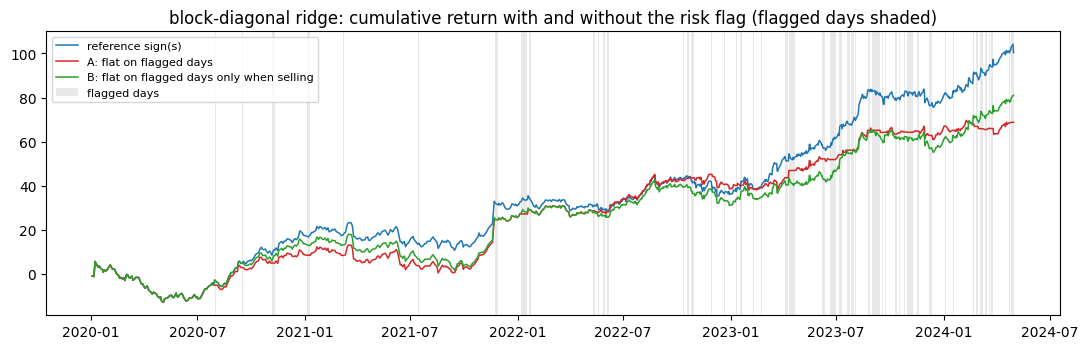

In [18]:
def rank_lag(s):
    return s.astype(float).expanding(min_periods=63).rank(pct=True).shift(1)

# declared before any result is read; the first entry is the primary flag
FLAGS = {
    "top tercile of rank(s_{t-1}) [primary]": lambda px: rank_lag(px["signal"]) > 2 / 3,
    "bottom tercile of rank(s_{t-1})": lambda px: rank_lag(px["signal"]) < 1 / 3,
    "top tercile of rank(|s_{t-1}|)": lambda px: rank_lag(px["signal"].abs()) > 2 / 3,
}

def scoreboard(r):
    r = r.astype(float)
    cum = r.cumsum()
    return pd.Series({
        "n": len(r), "mean": float(r.mean()),
        "Sharpe_ann": float(r.mean() / r.std(ddof=1) * np.sqrt(252)),
        "vol_ann": float(r.std(ddof=1) * np.sqrt(252)),
        "worst_day": float(r.min()),
        "maxDD": float((cum - cum.cummax()).min()),
        "ex_kurt": float(r.kurt()),
    })

def nw_t(d):
    d = np.asarray(d, float)
    lag = int(np.floor(1.5 * len(d) ** (1 / 3)))
    f = sm.OLS(d, np.ones((len(d), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lag})
    return float(f.tvalues[0]), lag

def sharpe(a):
    a = np.asarray(a, float)
    return float(a.mean() / a.std(ddof=1) * np.sqrt(252))

def boot_dsharpe(a, b, B=2000):
    rng = np.random.default_rng(0)
    n = len(a); blen = int(np.ceil(n ** (1 / 3))); nblk = int(np.ceil(n / blen))
    a = np.asarray(a, float); b = np.asarray(b, float); out = np.empty(B)
    for i in range(B):
        starts = rng.integers(0, n - blen + 1, nblk)
        idx = np.concatenate([np.arange(s, s + blen) for s in starts])[:n]
        out[i] = sharpe(a[idx]) - sharpe(b[idx])
    return np.percentile(out, [2.5, 97.5])

def apply_rules(px, flag):
    ref = px["pos"] * px["R"]
    sell = px["pos"] < 0
    return {
        "reference sign(s)": ref,
        "A: flat on flagged days": ref.where(~flag, 0.0),
        "B: flat on flagged days only when selling": ref.where(~(flag & sell), 0.0),
        "reference always-short": -px["R"],
        "A on always-short": (-px["R"]).where(~flag, 0.0),
    }

def placebo(px, flag, B=2000):
    # random flag sets with the same number of flagged days; rule A and rule B analogues
    rng = np.random.default_rng(0)
    n = len(px); k = int(flag.sum())
    R = px["R"].to_numpy(float); pos = px["pos"].to_numpy(float); ref = pos * R
    sell = pos < 0
    def stats(r):
        cum = np.cumsum(r)
        return r.min(), (cum - np.maximum.accumulate(cum)).min(), sharpe(r)
    ref_w, ref_dd, ref_sh = stats(ref)
    rows = {"A": np.empty((B, 3)), "B": np.empty((B, 3))}
    for i in range(B):
        f = np.zeros(n, bool); f[rng.choice(n, k, replace=False)] = True
        ra = np.where(f, 0.0, ref); rb = np.where(f & sell, 0.0, ref)
        for key, r in (("A", ra), ("B", rb)):
            w, dd, sh = stats(r)
            rows[key][i] = (w - ref_w, dd - ref_dd, sh - ref_sh)
    return rows, (ref_w, ref_dd, ref_sh)

def pct_rank(sample, x):
    return 100.0 * float((sample <= x).mean())

# ---- causality gate (flags read only s up to t-1; R never enters the flag) ----
px0 = books["blk2"].loc[common]
prim = list(FLAGS)[0]
rng_g = np.random.default_rng(0)
for t in rng_g.choice(np.arange(70, len(px0) - 1), 10, replace=False):
    base = FLAGS[prim](px0).to_numpy()
    p1 = px0.copy(); p1.loc[p1.index[t:], "R"] *= 3.0
    p2 = px0.copy(); p2.loc[p2.index[t:], "signal"] *= 3.0
    f1 = FLAGS[prim](p1).to_numpy(); f2 = FLAGS[prim](p2).to_numpy()
    assert (f1[: t + 1] == base[: t + 1]).all() and (f2[: t + 1] == base[: t + 1]).all()
print("causality: flags for days <= t unchanged by perturbing R or s on days >= t (10 draws)")

# ---- reference gate ----
ref0 = px0["pos"] * px0["R"]
print(f"reference sign(s), block-diagonal ridge: n {len(ref0)} mean {ref0.mean():.4f} Sharpe {sharpe(ref0):.3f}")
assert len(ref0) == 871 and abs(ref0.mean() - 0.1152) < 5e-4 and abs(sharpe(ref0) - 1.631) < 5e-3

# ---- scoreboards, all models, all flags ----
rows = {}
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    for fname, fn in FLAGS.items():
        flag = fn(px).fillna(False).astype(bool)
        for rname, r in apply_rules(px, flag).items():
            s = scoreboard(r)
            s["flagged_days"] = int(flag.sum())
            s["flagged_sell_days"] = int((flag & (px["pos"] < 0)).sum())
            rows[(fname, rname, tag)] = s
tab = pd.DataFrame(rows).T
tab.index = pd.MultiIndex.from_tuples(tab.index, names=["flag", "rule", "model"])
for tag in MODEL_ORDER:
    safe = "".join(ch if ch.isalnum() else "_" for ch in tag)
    tab.xs(tag, level="model").to_csv(OUT / f"riskflag_summary_{safe}.csv")
print("saved riskflag_summary_<model>.csv in", OUT)

px = books["blk2"].loc[common]
MAIN = ("reference sign(s)", "A: flat on flagged days", "B: flat on flagged days only when selling")
for fname in FLAGS:
    flag = FLAGS[fname](px).fillna(False).astype(bool)
    print(f"\n=== flag: {fname} --- block-diagonal ridge, {len(px)} days ===")
    sub = tab.xs(fname, level="flag").xs("blk2", level="model")
    print(sub.to_string(float_format=lambda x: f"{x:+.4f}"))
    rr = px["pos"] * px["R"]
    print("what the flag bought: mean return on flagged days {:+.4f} vs unflagged {:+.4f}; mean |R| flagged {:.4f} vs unflagged {:.4f}; "
          "flagged {} days, of which {} sells".format(
              rr[flag].mean(), rr[~flag].mean(), px["R"].abs()[flag].mean(), px["R"].abs()[~flag].mean(),
              int(flag.sum()), int((flag & (px["pos"] < 0)).sum())))
    rules = apply_rules(px, flag)
    per_year = pd.DataFrame({k: rules[k].groupby(rules[k].index.year).min() for k in MAIN})
    print("per-year worst day:")
    print(per_year.to_string(float_format=lambda x: f"{x:+.3f}"))
    ref = rules[MAIN[0]]
    plc, (rw, rdd, rsh) = placebo(px, flag)
    pair_rows = []
    for key, rname in (("A", MAIN[1]), ("B", MAIN[2])):
        r = rules[rname]; d = r - ref
        t, lag = nw_t(d); lo, hi = boot_dsharpe(r, ref)
        real = (float(r.min() - rw), float((r.cumsum() - r.cumsum().cummax()).min() - rdd), sharpe(r) - rsh)
        pcts = [pct_rank(plc[key][:, j], real[j]) for j in range(3)]
        pair_rows.append({"rule": rname, "mean_delta": float(d.mean()), "NW_t": t, "nw_lag": lag,
                          "dSharpe": real[2], "boot_lo": lo, "boot_hi": hi,
                          "worst_day_change": real[0], "maxDD_change": real[1],
                          "placebo_pct_worst": pcts[0], "placebo_pct_maxDD": pcts[1], "placebo_pct_dSharpe": pcts[2]})
    pr = pd.DataFrame(pair_rows).set_index("rule")
    print("paired against the reference (Newey-West t on the daily difference; block-bootstrap 95% interval on the Sharpe change)")
    print("and placebo percentiles: where the realized change sits among 2000 random flag sets of the same size (higher = better than chance):")
    print(pr.to_string(float_format=lambda x: f"{x:+.3f}"))
    if fname == prim:
        pr.to_csv(OUT / "riskflag_paired_blk2.csv")

# ---- where the sell-side losses live, and what the primary flag sacrifices ----
flag = FLAGS[prim](px).fillna(False).astype(bool)
rk = rank_lag(px["signal"])
ref = px["pos"] * px["R"]
sell = px["pos"] < 0
terc = pd.cut(rk, [0.0, 1 / 3, 2 / 3, 1.0], labels=["bottom", "middle", "top"], include_lowest=True)
trows = []
for name in ("bottom", "middle", "top"):
    in_t = terc == name
    m = sell & in_t
    trows.append({"tercile of rank(s_{t-1})": name, "days": int(in_t.sum()),
                  "share that are sell days": float(sell[in_t].mean()),
                  "sell days": int(m.sum()), "mean |R| on sell days": float(px["R"].abs()[m].mean()),
                  "worst sell-day return": float(ref[m].min()), "sell days below -2": int((ref[m] < -2).sum())})
tterc = pd.DataFrame(trows).set_index("tercile of rank(s_{t-1})")
print("\nsell days by tercile of the lagged rank (the top tercile is the primary flag):")
print(tterc.to_string(float_format=lambda x: f"{x:+.3f}"))
tterc.to_csv(OUT / "riskflag_sell_terciles_blk2.csv")

worst10 = ref.nsmallest(10)
share_ret = float(ref[flag].sum() / ref.sum())
share_loss = float(worst10[flag.reindex(worst10.index)].sum() / worst10.sum())
rng_p = np.random.default_rng(0)
n, k = len(ref), int(flag.sum())
w10_mask = ref.index.isin(worst10.index)
plc_share = np.empty(2000)
for i in range(2000):
    f = np.zeros(n, bool)
    f[rng_p.choice(n, k, replace=False)] = True
    plc_share[i] = ref.to_numpy()[f & w10_mask].sum() / worst10.sum()
print(f"sacrifice versus protection: flagged days carry {100 * share_ret:.1f}% of the reference return "
      f"but only {100 * share_loss:.1f}% of the ten worst days' losses; "
      f"placebo percentile of that loss share {pct_rank(plc_share, share_loss):.0f} "
      f"(random flags of the same size cover more of the worst days than this flag on {100 - pct_rank(plc_share, share_loss):.0f}% of draws)")
print(f"worst day flagged: sign(s) {bool(flag.loc[ref.idxmin()])}, always-short {bool(flag.loc[(-px['R']).idxmin()])}")
absflag = (rank_lag(px["R"].abs()) > 2 / 3).fillna(False).astype(bool)
print("a no-forecast comparator, the top tercile of yesterday's realized |R|: mean |R| on flagged days "
      f"{px['R'].abs()[absflag].mean():.3f} vs unflagged {px['R'].abs()[~absflag].mean():.3f} "
      f"(the lagged-signal flag: {px['R'].abs()[flag].mean():.3f} vs {px['R'].abs()[~flag].mean():.3f})")

flag = FLAGS[prim](px).fillna(False).astype(bool)
rules = apply_rules(px, flag)
fig, ax = plt.subplots(figsize=(11, 3.6))
for k, c in zip(MAIN, ("C0", "C3", "C2")):
    ax.plot(px.index, rules[k].cumsum().values, lw=1.1, color=c, label=k)
lo_y, hi_y = ax.get_ylim()
ax.fill_between(px.index, lo_y, hi_y, where=flag.to_numpy(), color="0.85", alpha=0.6, lw=0, label="flagged days")
ax.set_ylim(lo_y, hi_y)
ax.set_title("block-diagonal ridge: cumulative return with and without the risk flag (flagged days shaded)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "riskflag_cum_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "riskflag_cum_blk2.png")
display(fig)
plt.close(fig)


## 16. The body itself: a same-strike straddle against the nearest out-of-the-money pair

Every book in the deck is built on the same package: the nearest
out-of-the-money call (smallest listed strike at or above the 15:30
index level) and the nearest out-of-the-money put (largest strike at or
below it). SPX strikes sit five points apart and the index almost never
lands on one, so that package is a five-point-wide strangle on more
than 99% of days (the two strikes coincide on about 0.1% of days, and
sit ten apart on about 0.5% when a strike lacks quotes). This section
asks what changes if the body is instead a true straddle: both legs at
the single listed strike nearest to the index level, with live quotes
on both legs (an exact tie goes to the lower strike). The signal and
the position rules are unchanged; only the instrument differs. Both
bodies are settled in cash against the official close on the same
days.

**Three ways to measure the same dollars.** The two bodies differ by
one thing, and it can be written down. If the straddle strike is the
lower of the strangle's two strikes, straddle = strangle + a long
five-point call spread between them; if it is the upper strike,
straddle = strangle + a long five-point put spread. The cell verifies
this identity day by day from the leg quotes and then reports each
book in three frames: per dollar of premium (the deck's unit), per
dollar of **time value**, and in index points per package. The
time-value frame matters here because the straddle's premium contains
intrinsic value — the distance from the index level to its strike,
known at entry — that the strangle's premium does not; dividing by
total premium therefore dilutes the straddle's returns relative to
the strangle's by construction. The strangle's premium is all time
value, so its per-premium and per-time-value figures coincide. A
comparison across bodies is like-for-like only in the time-value frame
or in points.

Also reported: where the index sits on the strike grid (the offset
$|S-K^*|$ lies between 0 and 2.5 points) and both bodies' $\mathrm{sign}(s)$
results by tercile of that offset; the five-point vertical on its own —
its mean, its Newey–West $t$, and its share of the straddle's daily
variance — which decides whether the extra premium is edge or fairly
priced risk; crossed fills (sell at the bid, buy at the ask, on every
leg, with the in-the-money leg's relative spread printed against the
others); and the fraction-of-wealth rule of the deck's §14 on the
$\mathrm{sign}(s)$ book in the two return frames.

**What the numbers say.** In dollars the two $\mathrm{sign}(s)$ books are the
same book: about 0.34 index points per package-day each, a paired
difference of about −0.01 points per day with a $t$ near zero, and the
same worst day (the crash day, about −80 points). The extra premium
the straddle collects — a median 7.67 points against 5.35, of which
about 1.41 is intrinsic and 6.36 time value — is the five-point
vertical, and the vertical is fairly priced risk rather than edge: sold
on its own it earns about 0.11 points per day with a $t$ of about 1.5,
carries about 7% of the straddle's daily variance, is essentially
uncorrelated with the strangle, and the $\mathrm{sign}(s)$ rule has nothing
to say about it (about −0.01 points per day, $t$ near zero). It is a
small directional bet on which side of the strike the index closes;
the variance forecast does not inform it.

The frames then re-scale that one dollar P&L in three ways, and the
choice of denominator produces every apparent difference. Per dollar
of premium the straddle looks worse on the $\mathrm{sign}(s)$ rule — Sharpe
about 1.50 against 1.63, a mean lower by about 0.04 per day with a
Newey–West $t$ near −2.5, lower for all seven forecasts — and its
worst day looks halved (about −3.2 against −5.4). Both are the
intrinsic value in the denominator: the same dollar loss divided by a
larger, partly riskless premium. Per dollar of time value, the
like-for-like frame, the two bodies are indistinguishable — Sharpe
about 1.72 against 1.63 for the block-diagonal ridge, a paired $t$
near −0.4, the sign of the difference varying across the seven
forecasts — and the worst day is about −4.1 against −5.4, a smaller
gap that again reflects the denominator (the straddle's time value
exceeds the strangle's premium by about a point on a typical day). The
always-short control gains in every frame (about 0.44–0.50 against
0.28), but that gain is the vertical's 0.11 points per day, which is
not significant.

The fraction-of-wealth rule sees the same thing: the estimated
fraction is about 0.063 for either body in either frame. Because the
fraction is applied to the scaled return, each frame is a different
position-sizing rule on the same instrument — the per-time-value
straddle path holds more packages on days when time value is small —
and the terminal-wealth differences (about ×37 for the strangle, ×17
for the straddle per premium, ×61 per time value) are those sizing
rules, not a difference in edge. Where the index sits on the strike
grid does not separate the bodies either: both earn essentially nothing
in the third of days on which the index sits closest to a listed
strike and about the same as each other in the other two thirds — a
property of those days, not of either body. Crossed fills favour the
strangle: the straddle's legs are not wider in relative terms (about
5.1% and 5.5% of mid against 5.9%), but its package spread is larger
in points and its per-premium returns smaller, so after paying the
spread the $\mathrm{sign}(s)$ book scores about 0.90 against 1.10 per
premium (about 1.04 against 1.09 per time value), and always-short is
negative for both.

**Verdict.** The same-strike straddle is not a tail fix. The halved
per-premium worst day is intrinsic value in the denominator, the dollar
P&L is identical, and the difference between the bodies is a fairly
priced five-point vertical that the signal cannot time and that costs
more to cross. The strangle body stays: it is all time value, so its
per-premium figures are already the like-for-like ones, and it is
cheaper to fill. The compensation for the strike not sitting at the
index level is not a different instrument but a different denominator
— measure returns on time value, which is what the strangle's premium
already is. On XSP, where strikes are one point apart (ten SPX
points), the same construction would have a ten-point gap and the
question would have to be asked again.

the deck's body on the common days: gap between the two strikes (points), share of days
0.000000      0.110000
5.000000     99.430000
10.000000     0.460000
days scored: 871 of 871 common days have a same-strike straddle with live quotes on both legs
straddle strike is one of the strangle's two strikes on 100.0% of scored days; the call is the in-the-money leg on 51.9%
gate: strangle rows reproduce rule_table_blk2 (always short and sign(s) means) exactly


--- block-diagonal ridge: the two bodies in three frames ---
premium, median points: strangle 5.35, straddle 7.67 (of which intrinsic 1.41, time value 6.36)
the strangle expires worthless on 22.7% of days; the straddle settles within 1 point of its strike on 9.0%
[per premium]
                                            mean  Sharpe  worst_day    maxDD
body                        rule                                            
strangle (nearest OTM pair) always short +0.0201 +0.2836   -10.3160 -18.2945
                            sign(s)      +0.1152 +1.6313    -5.4225 -18.5503
straddle (same strike)      always short +0.0253 +0.5047    -5.6179 -19.4141
                            sign(s)      +0.0748 +1.4995    -3.2255 -13.3865
[per time value]
                                            mean  Sharpe  worst_day    maxDD
body                        rule                                            
strangle (nearest OTM pair) always short +0.0201 +0.2836   -10.3160 -18.2945
            

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\body_lab_cum_blk2.png


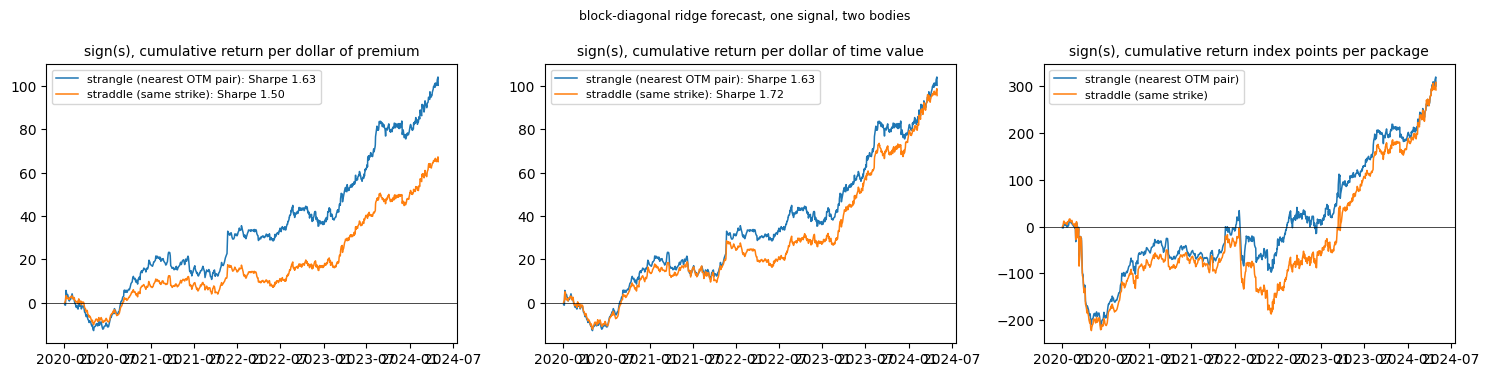

In [19]:
# --- the two bodies -----------------------------------------------------------
# strangle body: the deck's nearest out-of-the-money call and put (books[tag] carries it)
# straddle body: call and put at the single listed strike nearest to the 15:30 index level
_c = live[live["cp"] == "C"][["expiration", "strike", "bid", "ask", "mid"]].rename(
    columns={"bid": "bid_c", "ask": "ask_c", "mid": "mid_c"})
_p = live[live["cp"] == "P"][["expiration", "strike", "bid", "ask", "mid"]].rename(
    columns={"bid": "bid_p", "ask": "ask_p", "mid": "mid_p"})
_both = _c.merge(_p, on=["expiration", "strike"])
_both["strike"] = _both["strike"].astype(float)
_both["S"] = _both["expiration"].map(spot).astype(float)
_both = _both[np.isfinite(_both["S"])]
_both["dist"] = (_both["strike"] - _both["S"]).abs()
# nearest strike with live quotes on both legs; an exact tie goes to the lower strike
strad = _both.sort_values(["expiration", "dist", "strike"]).groupby("expiration", as_index=False).first()
_emap = atm.reset_index()[["day", "expiration", "S_close", "K_c", "K_p", "mid_c", "mid_p"]].rename(
    columns={"mid_c": "sg_mid_c", "mid_p": "sg_mid_p"})
strad = strad.merge(_emap, on="expiration", how="inner").set_index("day").sort_index()
strad["K"] = strad["strike"]
strad["entry"] = strad["mid_c"] + strad["mid_p"]
strad["exit"] = (strad["S_close"] - strad["K"]).abs()
strad = strad[np.isfinite(strad["entry"]) & (strad["entry"] > 0) & np.isfinite(strad["exit"])].copy()
strad["R"] = strad["exit"] / strad["entry"] - 1.0
strad["offset"] = strad["dist"]                       # |S - K*|, the intrinsic value at entry
strad["time_value"] = strad["entry"] - strad["offset"]
strad["itm_leg"] = np.where(strad["S"] >= strad["K"], "call", "put")
# the 5-point vertical that turns the strangle into the straddle:
#   K* = K_p -> long call spread K_p/K_c ; K* = K_c -> long put spread K_c/K_p
_on_grid = (strad["K"] == strad["K_p"]) | (strad["K"] == strad["K_c"])
_is_low = strad["K"] == strad["K_p"]
strad["vert_entry"] = np.where(_is_low, strad["mid_c"] - strad["sg_mid_c"], strad["mid_p"] - strad["sg_mid_p"])
strad["vert_exit"] = np.where(
    _is_low,
    np.maximum(strad["S_close"] - strad["K_p"], 0.0) - np.maximum(strad["S_close"] - strad["K_c"], 0.0),
    np.maximum(strad["K_c"] - strad["S_close"], 0.0) - np.maximum(strad["K_p"] - strad["S_close"], 0.0),
)
strad.loc[~_on_grid, ["vert_entry", "vert_exit"]] = np.nan

gap = (atm.loc[common, "K_c"] - atm.loc[common, "K_p"]).round(2)
print("the deck's body on the common days: gap between the two strikes (points), share of days")
print((gap.value_counts(normalize=True).sort_index() * 100).round(2).to_string())
days = common.intersection(strad.index)
print(f"days scored: {len(days)} of {len(common)} common days have a same-strike straddle with live quotes on both legs")
print(f"straddle strike is one of the strangle's two strikes on {float(_on_grid.loc[days].mean()):.1%} of scored days; "
      f"the call is the in-the-money leg on {float((strad.loc[days, 'itm_leg'] == 'call').mean()):.1%}")


def bl_sharpe(a):
    a = np.asarray(a, float)
    return float(a.mean() / a.std(ddof=1) * np.sqrt(252))


def bl_nw(d):
    d = np.asarray(d, float)
    lag = int(np.floor(1.5 * len(d) ** (1 / 3)))
    f = sm.OLS(d, np.ones((len(d), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lag})
    return float(f.params[0]), float(f.tvalues[0]), lag


def bl_boot(a, b, B=2000):
    rng = np.random.default_rng(0)
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a); blen = int(np.ceil(n ** (1 / 3))); nblk = int(np.ceil(n / blen))
    out = np.empty(B)
    for i in range(B):
        starts = rng.integers(0, n - blen + 1, nblk)
        idx = np.concatenate([np.arange(s, s + blen) for s in starts])[:n]
        out[i] = bl_sharpe(a[idx]) - bl_sharpe(b[idx])
    return np.percentile(out, [2.5, 97.5])


def bl_kelly(rs):
    mu = rs.expanding(min_periods=63).mean().shift(1)
    m2 = (rs**2).expanding(min_periods=63).mean().shift(1)
    cap = 1.0 / rs.expanding(min_periods=1).min().shift(1).abs()
    return np.minimum((mu / m2).clip(lower=0.0), cap).fillna(0.0)


def bl_wealth(f, r):
    fac = 1.0 + np.asarray(f, float) * np.asarray(r, float)
    assert (fac > 0).all()
    w = np.cumprod(fac)
    return {"g_ann": 252.0 * float(np.mean(np.log(fac))), "terminal": float(w[-1]),
            "maxDD": float((w / np.maximum.accumulate(w) - 1.0).min()), "worst_day_factor": float(fac.min())}


def bl_row(rp):
    cum = rp.cumsum()
    return {"mean": float(rp.mean()), "Sharpe": bl_sharpe(rp), "worst_day": float(rp.min()),
            "maxDD": float((cum - cum.cummax()).min())}


# gate: the strangle rows must reproduce the published rule table before anything is compared
_rt = pd.read_csv(OUT / "rule_table_blk2.csv", index_col=0)
_pxg = books["blk2"].loc[common]
assert abs(float((-_pxg["R"]).mean()) - float(_rt.loc["always short", "mean"])) < 1e-9
assert abs(float((_pxg["pos"] * _pxg["R"]).mean()) - float(_rt.loc["sign(s)", "mean"])) < 1e-9
print("gate: strangle rows reproduce rule_table_blk2 (always short and sign(s) means) exactly")

BODIES = ("strangle (nearest OTM pair)", "straddle (same strike)")
RULES = ("always short", "sign(s)")
FRAMES = ("per premium", "per time value", "index points")
score, paired, kelly_rows = {}, {}, {}
for tag in MODEL_ORDER:
    px = books[tag].loc[days]
    st = strad.loc[days]
    # three frames: per dollar of premium, per dollar of time value, index points per package
    frames = {
        BODIES[0]: {"per premium": px["R"], "per time value": px["R"], "index points": px["exit"] - px["entry"]},
        BODIES[1]: {"per premium": st["R"], "per time value": (st["exit"] - st["entry"]) / st["time_value"],
                    "index points": st["exit"] - st["entry"]},
    }
    q = {"always short": pd.Series(-1.0, index=days), "sign(s)": px["pos"].astype(float)}
    rp = {}
    for b in BODIES:
        for rule, qq in q.items():
            for fr in FRAMES:
                rp[(b, rule, fr)] = qq * frames[b][fr]
                row = bl_row(qq * frames[b][fr])
                row["n"] = int(len(days))
                row["premium_median"] = float((px if b == BODIES[0] else st)["entry"].median())
                row["pin_share"] = float(((px if b == BODIES[0] else st)["R"] <= -0.999).mean())
                score[(LABEL[tag], b, rule, fr)] = row
    for rule in RULES:
        for fr in ("per premium", "per time value"):
            a, b_ = rp[(BODIES[1], rule, fr)], rp[(BODIES[0], rule, fr)]
            m, t, lag = bl_nw(a - b_)
            lo, hi = bl_boot(a, b_)
            paired[(LABEL[tag], rule, fr)] = {"mean_diff": m, "NW_t": t, "lag": lag,
                                              "dSharpe": bl_sharpe(a) - bl_sharpe(b_), "dSharpe_lo": lo, "dSharpe_hi": hi}
    for b in BODIES:
        for fr in ("per premium", "per time value"):
            r = rp[(b, "sign(s)", fr)]
            fk = bl_kelly(r)
            row = {"mean_f": float(fk.mean()), **bl_wealth(fk, r)}
            half = bl_wealth(fk / 2, r)
            row["half_terminal"] = half["terminal"]; row["half_worst_day_factor"] = half["worst_day_factor"]
            kelly_rows[(LABEL[tag], b, fr)] = row
    if tag == "blk2":
        blk2_rp, blk2_px, blk2_st = rp, px, st

score_tab = pd.DataFrame(score).T
score_tab.index = pd.MultiIndex.from_tuples(score_tab.index, names=["model", "body", "rule", "frame"])
score_tab.to_csv(OUT / "body_lab_scoreboard.csv")
paired_tab = pd.DataFrame(paired).T
paired_tab.index = pd.MultiIndex.from_tuples(paired_tab.index, names=["model", "rule", "frame"])
paired_tab.to_csv(OUT / "body_lab_paired.csv")
kelly_tab = pd.DataFrame(kelly_rows).T
kelly_tab.index = pd.MultiIndex.from_tuples(kelly_tab.index, names=["model", "body", "frame"])
kelly_tab.to_csv(OUT / "body_lab_kelly.csv")

px, st = blk2_px, blk2_st
print("--- block-diagonal ridge: the two bodies in three frames ---")
print(f"premium, median points: strangle {float(px['entry'].median()):.2f}, straddle {float(st['entry'].median()):.2f} "
      f"(of which intrinsic {float(st['offset'].median()):.2f}, time value {float(st['time_value'].median()):.2f})")
print(f"the strangle expires worthless on {float((px['R'] <= -0.999).mean()):.1%} of days; "
      f"the straddle settles within 1 point of its strike on {float((st['exit'] < 1.0).mean()):.1%}")
for fr in FRAMES:
    print(f"[{fr}]")
    print(score_tab.xs((LABEL["blk2"], fr), level=("model", "frame"))[["mean", "Sharpe", "worst_day", "maxDD"]]
          .to_string(float_format=lambda x: f"{x:+.4f}"))
print("--- paired daily difference, straddle minus strangle, block-diagonal ridge ---")
print(paired_tab.xs(LABEL["blk2"], level="model").to_string(float_format=lambda x: f"{x:+.3f}"))
print("--- all seven forecasts: change in Sharpe from switching to the straddle body ---")
print(paired_tab["dSharpe"].unstack(["rule", "frame"]).to_string(float_format=lambda x: f"{x:+.3f}"))

# per-year Sharpe, both bodies, both rules, per premium and per time value
per_year = pd.DataFrame({(b, rule, fr): blk2_rp[(b, rule, fr)].groupby(blk2_rp[(b, rule, fr)].index.year).apply(bl_sharpe)
                         for b in BODIES for rule in RULES for fr in ("per premium", "per time value")})
per_year.columns = pd.MultiIndex.from_tuples(per_year.columns, names=["body", "rule", "frame"])
per_year.to_csv(OUT / "body_lab_per_year_blk2.csv")
print("--- per-year Sharpe, block-diagonal ridge, sign(s) ---")
print(per_year.xs("sign(s)", level="rule", axis=1).to_string(float_format=lambda x: f"{x:+.2f}"))

# where spot sits on the strike grid: does the straddle's result depend on it?
off = st["offset"]
print("--- offset |S - K*| at entry: median "
      f"{float(off.median()):.2f} points; above 1.25 on {float((off > 1.25).mean()):.1%} of days ---")
terc = pd.qcut(off, 3, labels=["near the strike", "middle", "far from the strike"])
for fr in ("per premium", "per time value"):
    tab = {}
    for b in BODIES:
        r = blk2_rp[(b, "sign(s)", fr)]
        g = r.groupby(terc, observed=True)
        tab[(b, "n")] = g.size(); tab[(b, "mean")] = g.mean(); tab[(b, "Sharpe")] = g.apply(bl_sharpe); tab[(b, "worst")] = g.min()
    tab = pd.DataFrame(tab)
    print(f"sign(s) by tercile of the straddle's offset, both bodies on the same days [{fr}]")
    print(tab.to_string(float_format=lambda x: f"{x:+.3f}"))
    tab.to_csv(OUT / f"body_lab_offset_{fr.replace(' ', '_')}_blk2.csv")

# the identity: short straddle = short strangle + short 5-point vertical between the two strikes
grid = np.isfinite(st["vert_entry"])
strad_short = (st["entry"] - st["exit"])[grid]
sg_short = (px["entry"] - px["exit"])[grid]
vert_short = (st["vert_entry"] - st["vert_exit"])[grid]
resid = float((strad_short - sg_short - vert_short).abs().max())
print(f"--- decomposition on {int(grid.sum())} days where the straddle strike is one of the strangle's strikes; "
      f"max identity residual {resid:.2e} points ---")
m_v, t_v, lag_v = bl_nw(vert_short)
print(f"short 5-point vertical alone: mean {m_v:+.3f} points/day (Newey-West t {t_v:+.2f}, lag {lag_v}); "
      f"premium collected median {float(st.loc[grid, 'vert_entry'].median()):.2f} of a 5-point maximum loss")
print(f"variance shares of the short straddle: strangle {float(np.cov(sg_short, strad_short)[0, 1] / strad_short.var(ddof=1)):.3f}, "
      f"vertical {float(np.cov(vert_short, strad_short)[0, 1] / strad_short.var(ddof=1)):.3f}; "
      f"var(vertical)/var(straddle) {float(vert_short.var(ddof=1) / strad_short.var(ddof=1)):.3f}; "
      f"corr(vertical, strangle) {float(np.corrcoef(vert_short, sg_short)[0, 1]):+.3f}")
ls_v = (px["pos"].astype(float) * (st["vert_exit"] - st["vert_entry"]))[grid]
m_lv, t_lv, _ = bl_nw(ls_v)
print(f"the vertical under the sign(s) rule: mean {m_lv:+.3f} points/day (t {t_lv:+.2f})")
pd.DataFrame({"straddle_short_pts": strad_short, "strangle_short_pts": sg_short, "vertical_short_pts": vert_short}).to_csv(
    OUT / "body_lab_decomposition_blk2.csv")

print("--- fraction of wealth (sign(s)), all forecasts ---")
print(kelly_tab.to_string(float_format=lambda x: f"{x:+.3f}"))


# --- realistic fills: sell at the bid, buy at the ask, on every leg -----------
def _leg_ok(bid, ask, sold):
    b = pd.to_numeric(bid, errors="coerce"); a = pd.to_numeric(ask, errors="coerce")
    base = np.isfinite(b) & np.isfinite(a) & (a >= b) & (b >= 0)
    return base & (b > 0) if sold else base & (a > 0)


pos = px["pos"].astype(float)
ok = pd.Series(True, index=days)
for fr_ in (px, st):
    for bcol, acol in (("bid_c", "ask_c"), ("bid_p", "ask_p")):
        ok &= _leg_ok(fr_[bcol], fr_[acol], True)                       # the sold legs (always short sells both every day)
        ok &= _leg_ok(fr_[bcol], fr_[acol], False)                      # the bought legs on long days
print(f"--- crossed fills: {int(ok.sum())} of {len(days)} days have usable bid/ask on all four legs of both bodies ---")
fills, spreads = {}, {}
for b, fr_ in ((BODIES[0], px), (BODIES[1], st)):
    bid_sum = fr_["bid_c"] + fr_["bid_p"]; ask_sum = fr_["ask_c"] + fr_["ask_p"]
    half = ((fr_["ask_c"] - fr_["bid_c"]) + (fr_["ask_p"] - fr_["bid_p"])) / 2.0
    for rule, qq in (("always short", pd.Series(-1.0, index=days)), ("sign(s)", pos)):
        entry_fill = bid_sum.where(qq < 0, ask_sum)
        rpf = (qq * (fr_["exit"] / entry_fill - 1.0))[ok]
        rpm = (qq * fr_["R"])[ok]
        tv = fr_["time_value"] if b == BODIES[1] else fr_["entry"]
        rpf_tv = (qq * (fr_["exit"] - entry_fill) / tv)[ok]
        rpm_tv = (qq * (fr_["exit"] - fr_["entry"]) / tv)[ok]
        fills[(b, rule)] = {"n": int(ok.sum()), "Sharpe_mid": bl_sharpe(rpm), "Sharpe_crossed": bl_sharpe(rpf),
                            "Sharpe_mid_tv": bl_sharpe(rpm_tv), "Sharpe_crossed_tv": bl_sharpe(rpf_tv),
                            "mean_mid": float(rpm.mean()), "mean_crossed": float(rpf.mean()),
                            "half_spread_over_premium_median": float((half / fr_["entry"])[ok].median())}
    rel_c = ((fr_["ask_c"] - fr_["bid_c"]) / fr_["mid_c"])[ok]; rel_p = ((fr_["ask_p"] - fr_["bid_p"]) / fr_["mid_p"])[ok]
    if b == BODIES[1]:
        itm_call = (fr_["itm_leg"] == "call")[ok]
        spreads["straddle, in-the-money leg"] = float(pd.concat([rel_c[itm_call], rel_p[~itm_call]]).median())
        spreads["straddle, out-of-the-money leg"] = float(pd.concat([rel_c[~itm_call], rel_p[itm_call]]).median())
    else:
        spreads["strangle call"] = float(rel_c.median()); spreads["strangle put"] = float(rel_p.median())
fills_tab = pd.DataFrame(fills).T
fills_tab.index = pd.MultiIndex.from_tuples(fills_tab.index, names=["body", "rule"])
print(fills_tab.to_string(float_format=lambda x: f"{x:+.4f}"))
print("median relative spread (ask - bid) / mid by leg:")
print(pd.Series(spreads).to_string(float_format=lambda x: f"{x:.3f}"))
fills_tab.to_csv(OUT / "body_lab_fills_blk2.csv")
pd.Series(spreads, name="rel_spread").to_csv(OUT / "body_lab_spreads_blk2.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for b, c in zip(BODIES, ("C0", "C1")):
    for ax, fr, ttl in ((axes[0], "per premium", "per dollar of premium"), (axes[1], "per time value", "per dollar of time value"),
                        (axes[2], "index points", "index points per package")):
        r = blk2_rp[(b, "sign(s)", fr)]
        lab = f"{b}: Sharpe {bl_sharpe(r):.2f}" if fr != "index points" else b
        ax.plot(r.index, r.cumsum().values, lw=1.1, color=c, label=lab)
        ax.set_title(f"sign(s), cumulative return {ttl}", fontsize=10)
for ax in axes:
    ax.axhline(0, color="k", lw=0.5); ax.legend(fontsize=8)
fig.suptitle("block-diagonal ridge forecast, one signal, two bodies", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "body_lab_cum_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "body_lab_cum_blk2.png")
display(fig)
plt.close(fig)
